# Student First-Year Persistence — ML Pipeline
### Neural Networks Course Project

---

**Goal:** Predict whether a first-year college student will persist (complete the year) based on academic and demographic features.

**Target variable:** `persistence` → 1 = persisted, 0 = did not persist

**Pipeline overview:**

```
① Load  →  ② Split (Train/Val/Test)  →  ③ Visualize (train only)
→  ④ Transform  →  ⑤ Impute  →  ⑥ Scale  →  ⑦ KNN hs_avg
→  ⑧ Train Model  →  ⑨ Tune  →  ⑩ Evaluate
```

---
## CELL 1 — Install & Import Libraries

In [41]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Install & Import Libraries
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing  import StandardScaler
from sklearn.impute          import KNNImputer

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.figsize' : (12, 5),
    'axes.titlesize' : 14,
    'axes.labelsize' : 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

CLR_PERSIST  = '#2ECC71'
CLR_DROPOUT  = '#E74C3C'
CLR_NEUTRAL  = '#3498DB'
CLR_ACCENT   = '#F39C12'

RANDOM_STATE = 42

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## CELL 2 — Load Dataset

In [42]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Load Dataset
# ─────────────────────────────────────────────────────────────────────────────

df_raw = pd.read_csv('Student data.csv')

print(f'Dataset shape  :  {df_raw.shape[0]} rows  ×  {df_raw.shape[1]} columns')
print()
print('Original column names (raw):')
for i, col in enumerate(df_raw.columns, 1):
    print(f'  {i:>2}. {col}')

df_raw.head(5)

Dataset shape  :  1437 rows  ×  15 columns

Original column names (raw):
   1. First Term Gpa' numeric
   2. Second Term Gpa' numeric
   3. First Language' numeric
   4.  Funding numeric
   5. School numeric
   6. FastTrack numeric
   7. Coop numeric
   8.  Residency numeric
   9. Gender numeric
  10. Previous Education' numeric
  11. Age Group' numeric
  12. High School Average Mark' numeric
  13. Math Score' numeric
  14. English Grade' numeric
  15. FirstYearPersistence {1,0}


,First Term Gpa' numeric,Second Term Gpa' numeric,First Language' numeric,Funding numeric,School numeric,FastTrack numeric,Coop numeric,Residency numeric,Gender numeric,Previous Education' numeric,Age Group' numeric,High School Average Mark' numeric,Math Score' numeric,English Grade' numeric,"FirstYearPersistence {1,0}"
0,0,0,1,2,6,2,1,1,2,1,1,59,16,7,1
1,2.5,2,3,4,6,1,2,2,2,1,3,?,?,7,1
2,4.25,3.923077,1,1,6,2,1,1,1,2,3,92,41,9,1
3,3.020833,2.321429,3,4,6,1,2,2,2,2,3,?,?,8,1
4,4.275,4.326923,1,2,6,1,1,1,1,2,3,97,?,9,1


---
## CELL 3 — Train / Validation / Test Split

> **Why here?** We split BEFORE any exploration so that:
> - Test set is never seen until final evaluation
> - All statistics (medians, modes, scalers) are fitted on training data only
> - No data leakage
>
> **Strategy:** stratified split to preserve class ratio in every subset.

In [43]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Train / Validation / Test Split  (stratified)
# ─────────────────────────────────────────────────────────────────────────────

df = df_raw.copy()

df.columns = [
    'first_term_gpa', 'second_term_gpa', 'first_language', 'funding',
    'school', 'fast_track', 'coop', 'residency', 'gender',
    'prev_education', 'age_group', 'hs_avg', 'math_score',
    'english_grade', 'persistence'
]

df.replace('?', np.nan, inplace=True)

numeric_cols = ['first_term_gpa', 'second_term_gpa', 'hs_avg', 'math_score',
                'first_language', 'prev_education', 'age_group', 'english_grade']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

X = df.drop(columns=['persistence'])
y = df['persistence']

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1176, random_state=RANDOM_STATE, stratify=y_temp
)

total = len(df)
print('═' * 55)
print(f'  Total rows          : {total}')
print('─' * 55)
print(f'  Train set         : {len(X_train):>5}  ({len(X_train)/total*100:.1f}%)')
print(f'  Validation set    : {len(X_val):>5}  ({len(X_val)/total*100:.1f}%)')
print(f'  Test set          : {len(X_test):>5}  ({len(X_test)/total*100:.1f}%)')
print('─' * 55)
print(f'  Class ratio (train) : persist={y_train.mean():.2%}  dropout={1-y_train.mean():.2%}')
print(f'  Class ratio (val)   : persist={y_val.mean():.2%}  dropout={1-y_val.mean():.2%}')
print(f'  Class ratio (test)  : persist={y_test.mean():.2%}  dropout={1-y_test.mean():.2%}')
print('═' * 55)

train_eda = X_train.copy()
train_eda['persistence'] = y_train.values

print('\nSplit complete.  All EDA below uses only train_eda.')

═══════════════════════════════════════════════════════
  Total rows          : 1437
───────────────────────────────────────────────────────
  Train set         :  1077  (74.9%)
  Validation set    :   144  (10.0%)
  Test set          :   216  (15.0%)
───────────────────────────────────────────────────────
  Class ratio (train) : persist=79.20%  dropout=20.80%
  Class ratio (val)   : persist=79.17%  dropout=20.83%
  Class ratio (test)  : persist=79.17%  dropout=20.83%
═══════════════════════════════════════════════════════

Split complete.  All EDA below uses only train_eda.


---
## VISUALIZATION SECTION

> Everything below explores **training data only.**

### CELL 4 — Column Names & Value Counts per Feature

In [44]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Column Names & Value Counts per Feature
# ─────────────────────────────────────────────────────────────────────────────

print('═' * 60)
print('  FEATURE OVERVIEW  (training set)')
print('═' * 60)

feature_meta = {
    'first_term_gpa' : ('Continuous',  '0.0 – 4.5'),
    'second_term_gpa': ('Continuous',  '0.0 – 4.5'),
    'first_language' : ('Nominal',     '1=English, 2=French/Other'),
    'funding'        : ('Nominal',     '1-9  (program type)'),
    'school'         : ('Nominal',     '1-7  (DROP → zero variance)'),
    'fast_track'     : ('Nominal',     '1=Yes, 2=No'),
    'coop'           : ('Nominal',     '1=Yes, 2=No'),
    'residency'      : ('Nominal',     '1=Domestic, 2=International'),
    'gender'         : ('Nominal',     '1=Female, 2=Male, 3=Neutral'),
    'prev_education' : ('Ordinal',     '1=HighSchool, 2=PostSecondary'),
    'age_group'      : ('Ordinal',     '1=≤18  … 10=66+'),
    'hs_avg'         : ('Continuous',  '0 – 100'),
    'math_score'     : ('Continuous',  '0 – 50'),
    'english_grade'  : ('Ordinal',     '1-11  CELPIP levels'),
    'persistence'    : ('TARGET',      '0=Dropout, 1=Persisted'),
}

for col, (dtype, desc) in feature_meta.items():
    n_unique  = train_eda[col].nunique(dropna=False)
    n_missing = train_eda[col].isnull().sum()
    print(f'\n -> {col:<20}  [{dtype}]  {desc}')
    print(f'     Unique values: {n_unique}  |  Missing: {n_missing}')
    vc = train_eda[col].value_counts(dropna=False).head(12)
    for val, cnt in vc.items():
        bar = '█' * int(cnt / max(vc) * 30)
        print(f'       {str(val):>8} : {cnt:>4}  {bar}')

════════════════════════════════════════════════════════════
  FEATURE OVERVIEW  (training set)
════════════════════════════════════════════════════════════

 -> first_term_gpa        [Continuous]  0.0 – 4.5
     Unique values: 587  |  Missing: 9
            0.0 :   59  ██████████████████████████████
            3.5 :   12  ██████
            4.0 :   11  █████
            2.0 :   10  █████
            nan :    9  ████
           2.75 :    8  ████
            2.5 :    8  ████
       4.285714 :    7  ███
           3.56 :    6  ███
            3.3 :    6  ███
       3.652174 :    6  ███
            4.5 :    6  ███

 -> second_term_gpa       [Continuous]  0.0 – 4.5
     Unique values: 587  |  Missing: 117
            nan :  117  ██████████████████████████████
            0.0 :   60  ███████████████
            3.5 :   12  ███
            4.0 :   10  ██
            3.0 :    9  ██
           3.25 :    8  ██
            2.5 :    8  ██
            4.5 :    7  █
            2.0 :    7  █
     

### CELL 5 — Missing Values Visualization

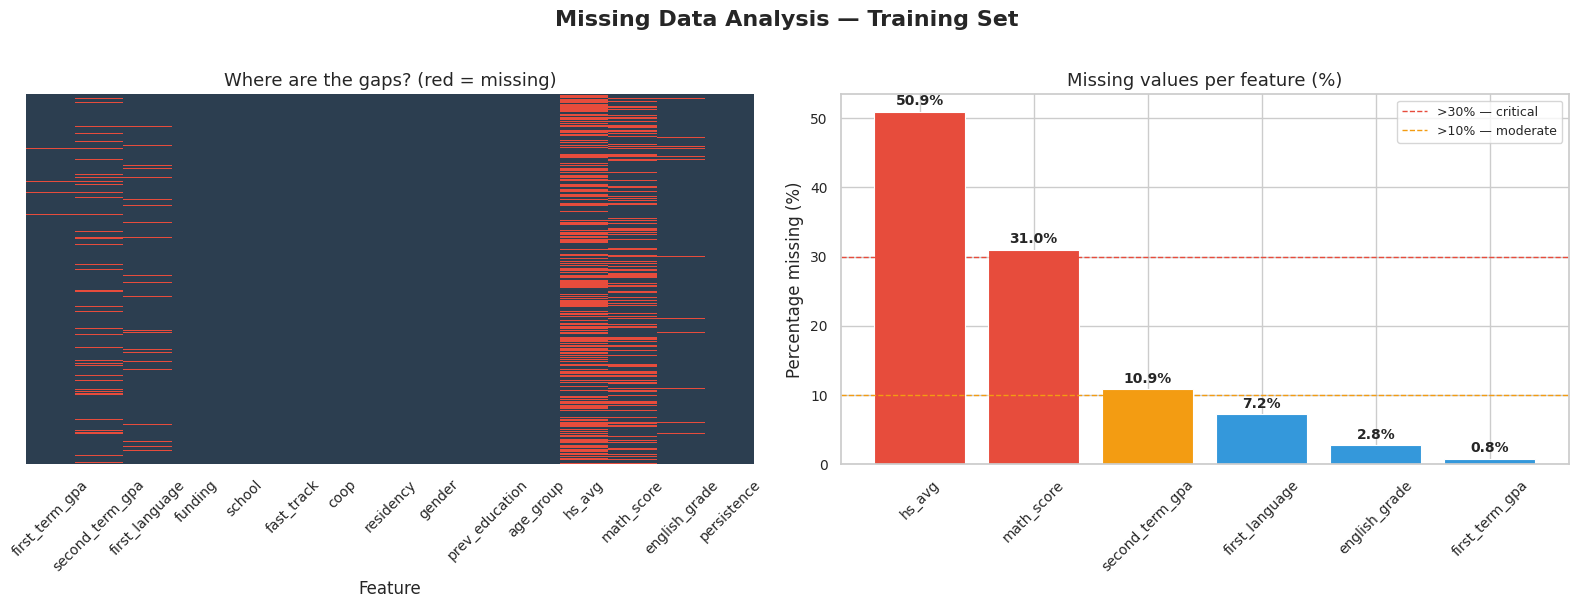


 Key insight:
   hs_avg is missing in 50.9% of training rows → heavy KNN imputation needed
   math_score missing in 31.0% → group-wise median imputation


In [45]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — Missing Values Visualization
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Missing Data Analysis — Training Set', fontsize=16, fontweight='bold', y=1.01)

# Left: Heatmap
sns.heatmap(
    train_eda.isnull(), cbar=False, yticklabels=False,
    cmap=sns.color_palette(['#2C3E50', '#E74C3C'], as_cmap=True),
    ax=axes[0]
)
axes[0].set_title('Where are the gaps? (red = missing)', fontsize=13)
axes[0].set_xlabel('Feature')
axes[0].tick_params(axis='x', rotation=45)

# Right: Bar chart of % missing
missing_pct = (train_eda.isnull().sum() / len(train_eda) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

colors = [CLR_DROPOUT if p > 30 else CLR_ACCENT if p > 10 else CLR_NEUTRAL
          for p in missing_pct]
bars = axes[1].bar(missing_pct.index, missing_pct.values, color=colors, edgecolor='white', linewidth=0.8)

for bar, pct in zip(bars, missing_pct.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[1].set_title('Missing values per feature (%)', fontsize=13)
axes[1].set_ylabel('Percentage missing (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(30, color=CLR_DROPOUT, linestyle='--', linewidth=1, label='>30% — critical')
axes[1].axhline(10, color=CLR_ACCENT,  linestyle='--', linewidth=1, label='>10% — moderate')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n Key insight:')
print(f'   hs_avg is missing in {missing_pct["hs_avg"]:.1f}% of training rows → heavy KNN imputation needed')
print(f'   math_score missing in {missing_pct["math_score"]:.1f}% → group-wise median imputation')

### CELL 6 — Understanding What We Are Predicting (Class Balance)

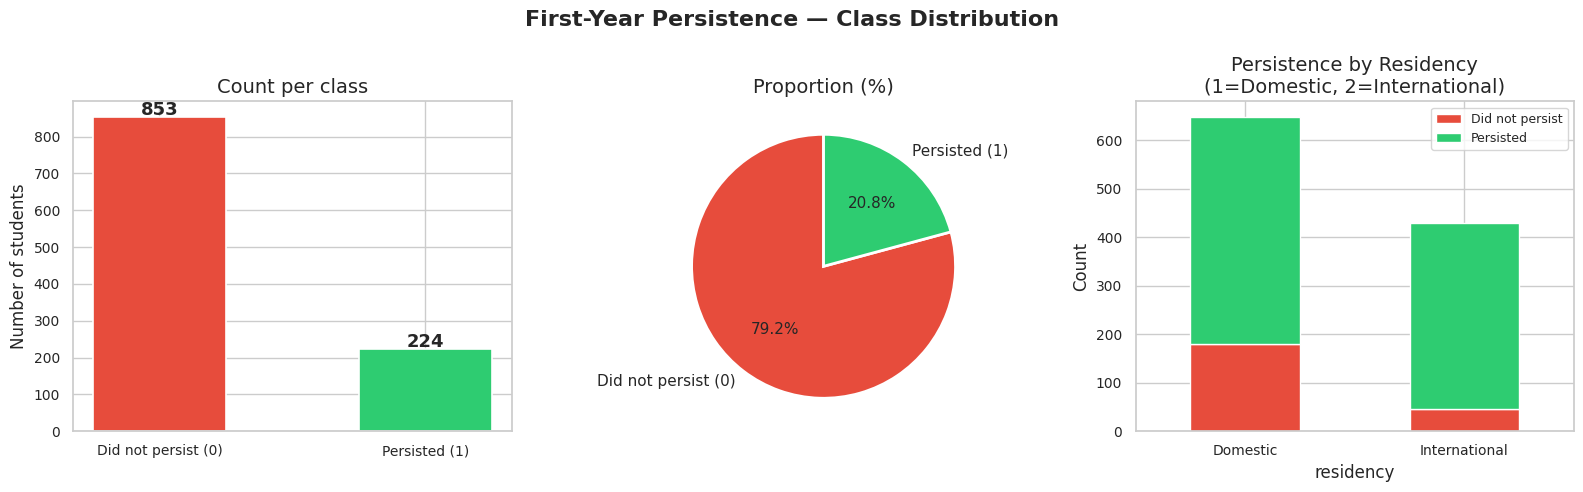

  Persisted       : 853 students  (79.2%)
  Did not persist : 224 students  (20.8%)

   Imbalance ratio: 3.8:1
  → During training we will use class_weight="balanced" to compensate.


In [46]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — Class Balance: What Are We Predicting?
# ─────────────────────────────────────────────────────────────────────────────

counts = train_eda['persistence'].value_counts()
labels = ['Did not persist (0)', 'Persisted (1)']
colors = [CLR_DROPOUT, CLR_PERSIST]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('First-Year Persistence — Class Distribution', fontsize=16, fontweight='bold')

# Bar chart
bars = axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.2, width=0.5)
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(v), ha='center', fontsize=13, fontweight='bold')
axes[0].set_title('Count per class')
axes[0].set_ylabel('Number of students')

# Pie chart
axes[1].pie(
    counts.values, labels=labels, autopct='%1.1f%%',
    colors=colors, startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 11}
)
axes[1].set_title('Proportion (%)')

# Stacked bar by group to show imbalance context
persist_by_residency = train_eda.groupby(['residency', 'persistence']).size().unstack(fill_value=0)
persist_by_residency.plot(
    kind='bar', stacked=True, ax=axes[2],
    color=[CLR_DROPOUT, CLR_PERSIST], edgecolor='white'
)
axes[2].set_title('Persistence by Residency\n(1=Domestic, 2=International)')
axes[2].set_ylabel('Count')
axes[2].set_xticklabels(['Domestic', 'International'], rotation=0)
axes[2].legend(['Did not persist', 'Persisted'], fontsize=9)

plt.tight_layout()
plt.savefig('class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

ratio = counts[1] / counts[0]
print(f'  Persisted       : {counts[1]} students  ({counts[1]/len(train_eda)*100:.1f}%)')
print(f'  Did not persist : {counts[0]} students  ({counts[0]/len(train_eda)*100:.1f}%)')
print(f'\n   Imbalance ratio: {ratio:.1f}:1')
print('  → During training we will use class_weight="balanced" to compensate.')

### CELL 7 — GPA Distributions (Persisted vs. Dropout)

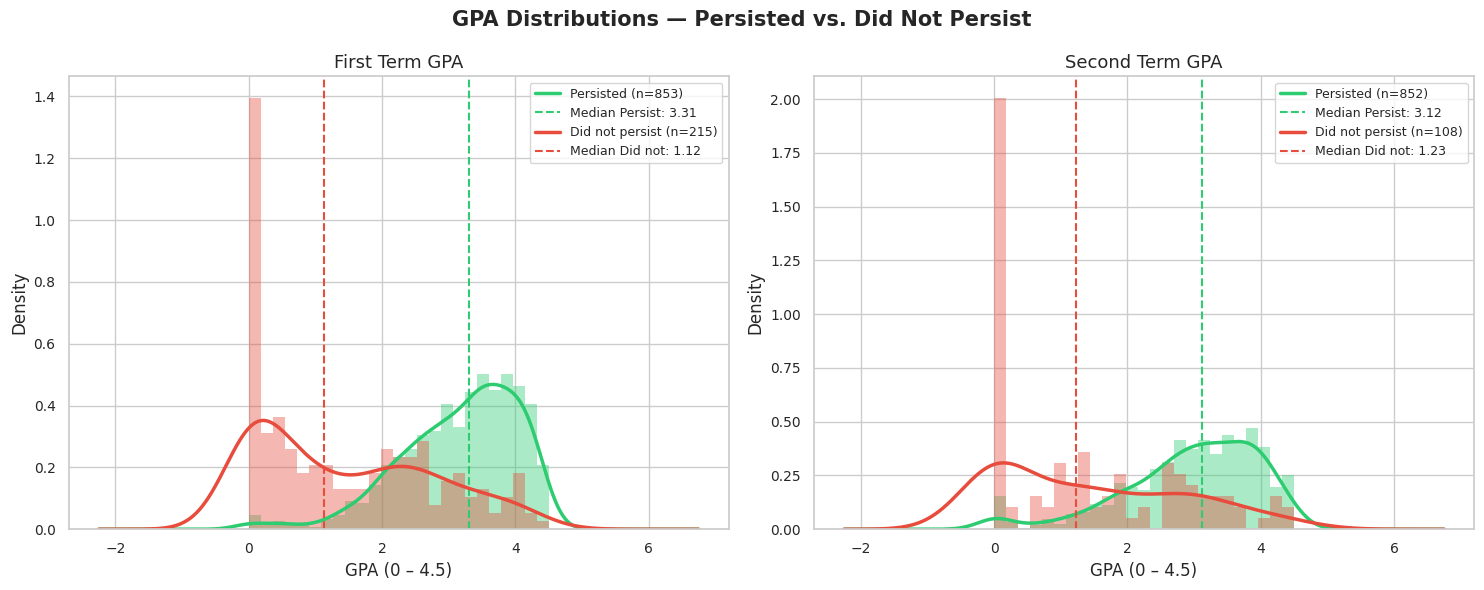

 Insight: Students who persist have noticeably higher GPA in both terms.
 GPA will likely be among the top predictive features.


In [47]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — GPA Distributions split by Persistence
# ─────────────────────────────────────────────────────────────────────────────

gpa_features = ['first_term_gpa', 'second_term_gpa']
titles       = ['First Term GPA', 'Second Term GPA']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('GPA Distributions — Persisted vs. Did Not Persist', fontsize=15, fontweight='bold')

for ax, col, title in zip(axes, gpa_features, titles):
    for label, color, name in [(1, CLR_PERSIST, 'Persisted'), (0, CLR_DROPOUT, 'Did not persist')]:
        subset = train_eda[train_eda['persistence'] == label][col].dropna()
        ax.hist(subset, bins=25, alpha=0.4, color=color, edgecolor='none', density=True)
        subset.plot.kde(ax=ax, color=color, linewidth=2.5, label=f'{name} (n={len(subset)})')
        ax.axvline(subset.median(), color=color, linestyle='--', linewidth=1.5,
                   label=f'Median {name[:7]}: {subset.median():.2f}')

    ax.set_title(title, fontsize=13)
    ax.set_xlabel('GPA (0 – 4.5)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('gpa_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print(' Insight: Students who persist have noticeably higher GPA in both terms.')
print(' GPA will likely be among the top predictive features.')

### CELL 8 — Categorical Feature Distributions

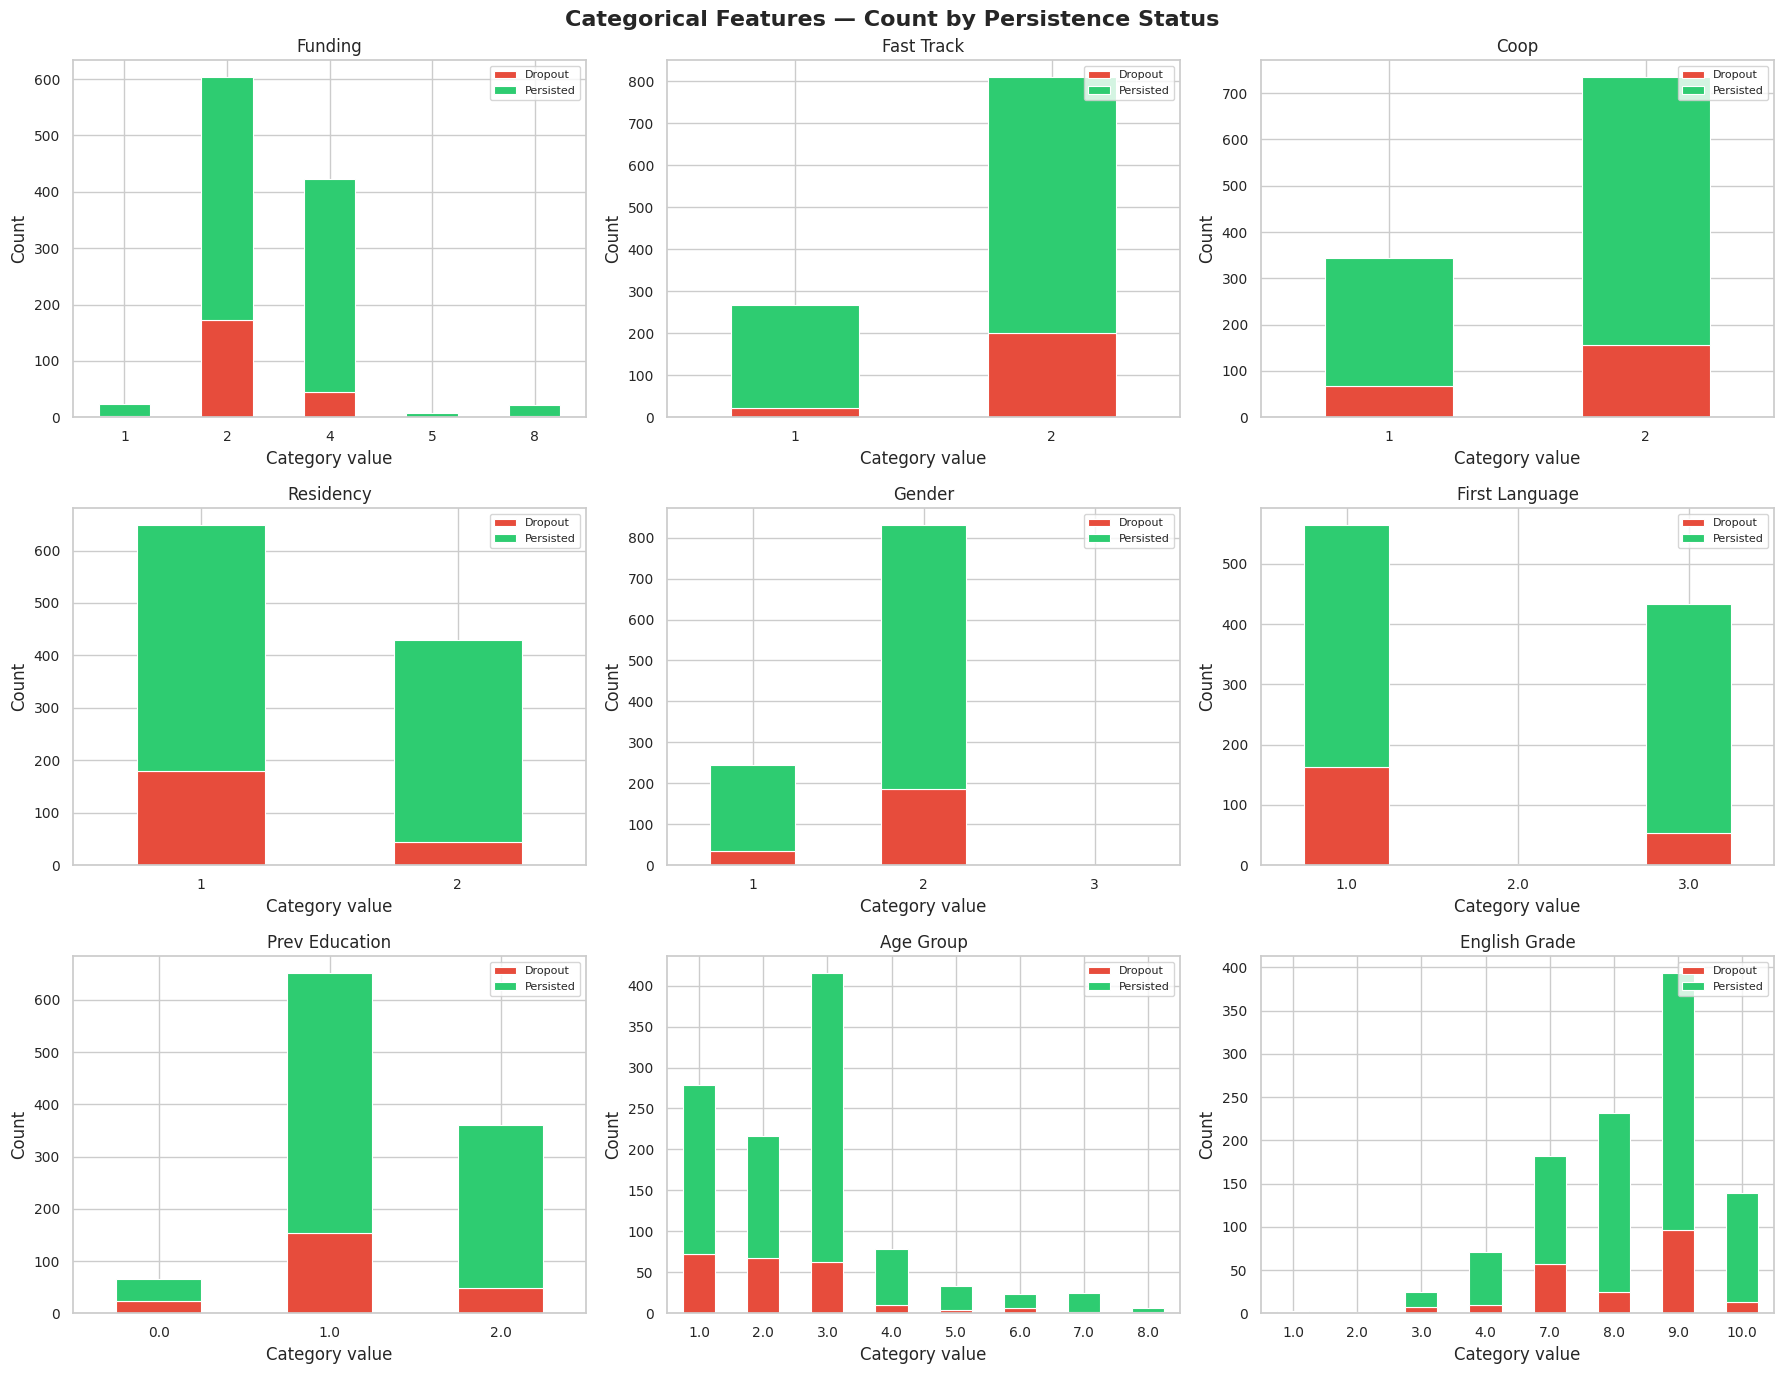

In [48]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — Categorical Feature Distributions
# ─────────────────────────────────────────────────────────────────────────────

cat_cols = ['funding', 'fast_track', 'coop', 'residency',
            'gender', 'first_language', 'prev_education', 'age_group', 'english_grade']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
fig.suptitle('Categorical Features — Count by Persistence Status', fontsize=16, fontweight='bold')

for i, col in enumerate(cat_cols):
    grouped = train_eda.groupby([col, 'persistence']).size().unstack(fill_value=0)
    grouped.plot(
        kind='bar', stacked=True, ax=axes[i],
        color=[CLR_DROPOUT, CLR_PERSIST],
        edgecolor='white', linewidth=0.8
    )
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=12)
    axes[i].set_xlabel('Category value')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(['Dropout', 'Persisted'], fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('categorical_features.png', dpi=150, bbox_inches='tight')
plt.show()

### CELL 9 — Correlation Matrix (Numeric Features)

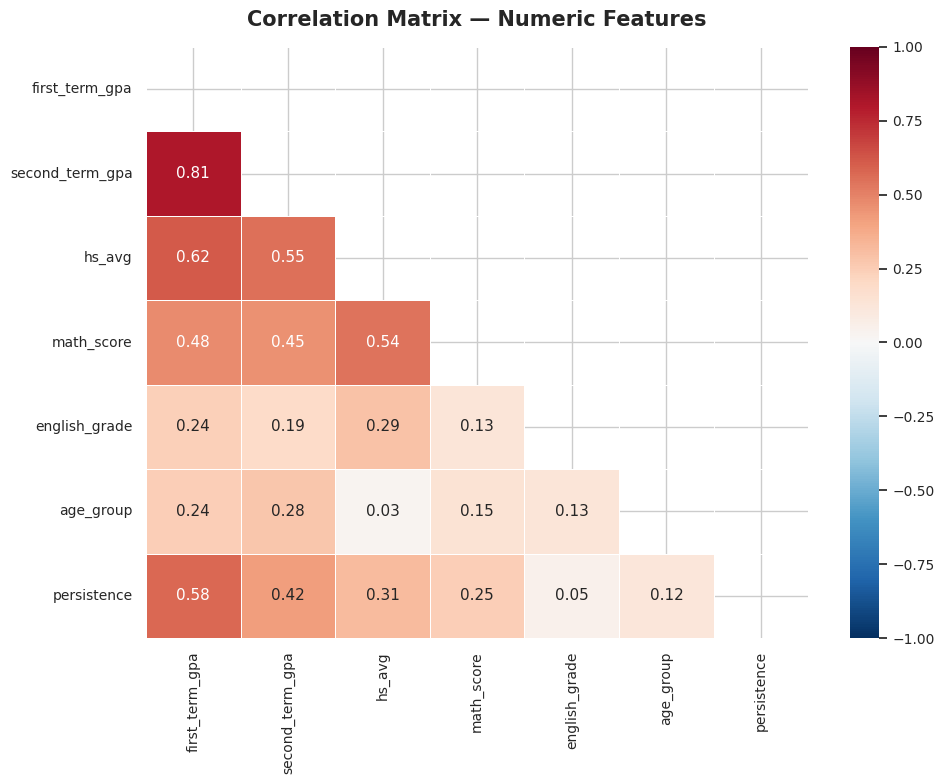


 Correlations with target  (persistence):
  first_term_gpa          +0.577  █████████████████
  second_term_gpa         +0.418  ████████████
  hs_avg                  +0.315  █████████
  math_score              +0.246  ███████
  age_group               +0.119  ███
  english_grade           +0.055  █


In [49]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 — Correlation Matrix — Numeric Features & Persistence
# ─────────────────────────────────────────────────────────────────────────────

num_cols  = ['first_term_gpa', 'second_term_gpa', 'hs_avg',
             'math_score', 'english_grade', 'age_group', 'persistence']
corr_data = train_eda[num_cols].copy()
corr      = corr_data.corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, mask=mask, linewidths=0.5,
    annot_kws={'size': 11}, vmin=-1, vmax=1
)
plt.title('Correlation Matrix — Numeric Features', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n Correlations with target  (persistence):')
top_corr = corr['persistence'].drop('persistence').sort_values(ascending=False)
for feat, val in top_corr.items():
    bar = '█' * int(abs(val) * 30)
    sign = '+' if val >= 0 else '-'
    print(f'  {feat:<22}  {sign}{abs(val):.3f}  {bar}')

### CELL 10 — First Language vs. Residency

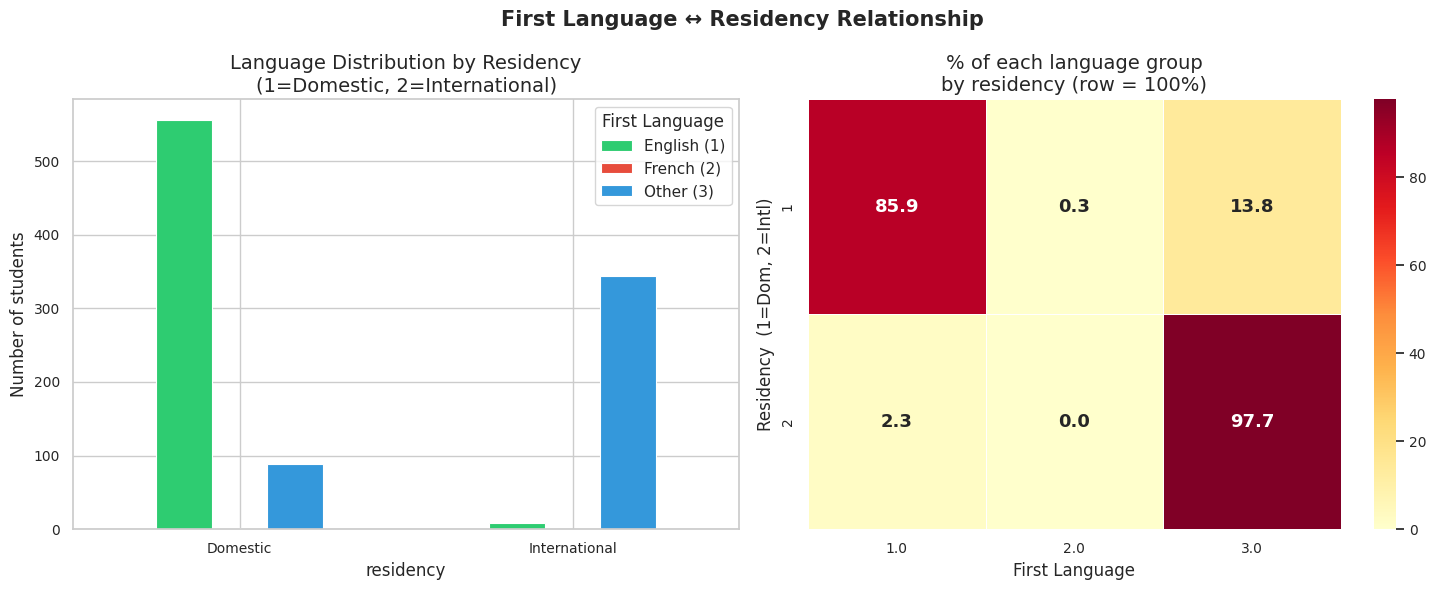

 Insight: Domestic students (residency=1) are almost entirely English-speaking (1).
 International students (residency=2) are mostly Other/French (2 or 3).
 → This confirms our imputation rule: missing Language → infer from Residency.


In [50]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 — First Language vs. Residency
# ─────────────────────────────────────────────────────────────────────────────
# We will use Residency to impute missing First Language values.

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('First Language ↔ Residency Relationship', fontsize=15, fontweight='bold')

lang_res = train_eda.groupby(['residency', 'first_language']).size().unstack(fill_value=0)
lang_res.plot(
    kind='bar', ax=axes[0],
    color=[CLR_PERSIST, CLR_DROPOUT, CLR_NEUTRAL],
    edgecolor='white', linewidth=0.8
)
axes[0].set_title('Language Distribution by Residency\n(1=Domestic, 2=International)')
axes[0].set_ylabel('Number of students')
axes[0].set_xticklabels(['Domestic', 'International'], rotation=0)
axes[0].legend(title='First Language', labels=['English (1)', 'French (2)', 'Other (3)'])

lang_res_pct = lang_res.div(lang_res.sum(axis=1), axis=0) * 100
sns.heatmap(
    lang_res_pct, annot=True, fmt='.1f', cmap='YlOrRd',
    ax=axes[1], linewidths=0.5,
    annot_kws={'size': 13, 'fontweight': 'bold'}
)
axes[1].set_title('% of each language group\nby residency (row = 100%)')
axes[1].set_xlabel('First Language')
axes[1].set_ylabel('Residency  (1=Dom, 2=Intl)')

plt.tight_layout()
plt.savefig('language_residency.png', dpi=150, bbox_inches='tight')
plt.show()

print(' Insight: Domestic students (residency=1) are almost entirely English-speaking (1).')
print(' International students (residency=2) are mostly Other/French (2 or 3).')
print(' → This confirms our imputation rule: missing Language → infer from Residency.')

### CELL 11 — HS Average Missing Data vs. Residency

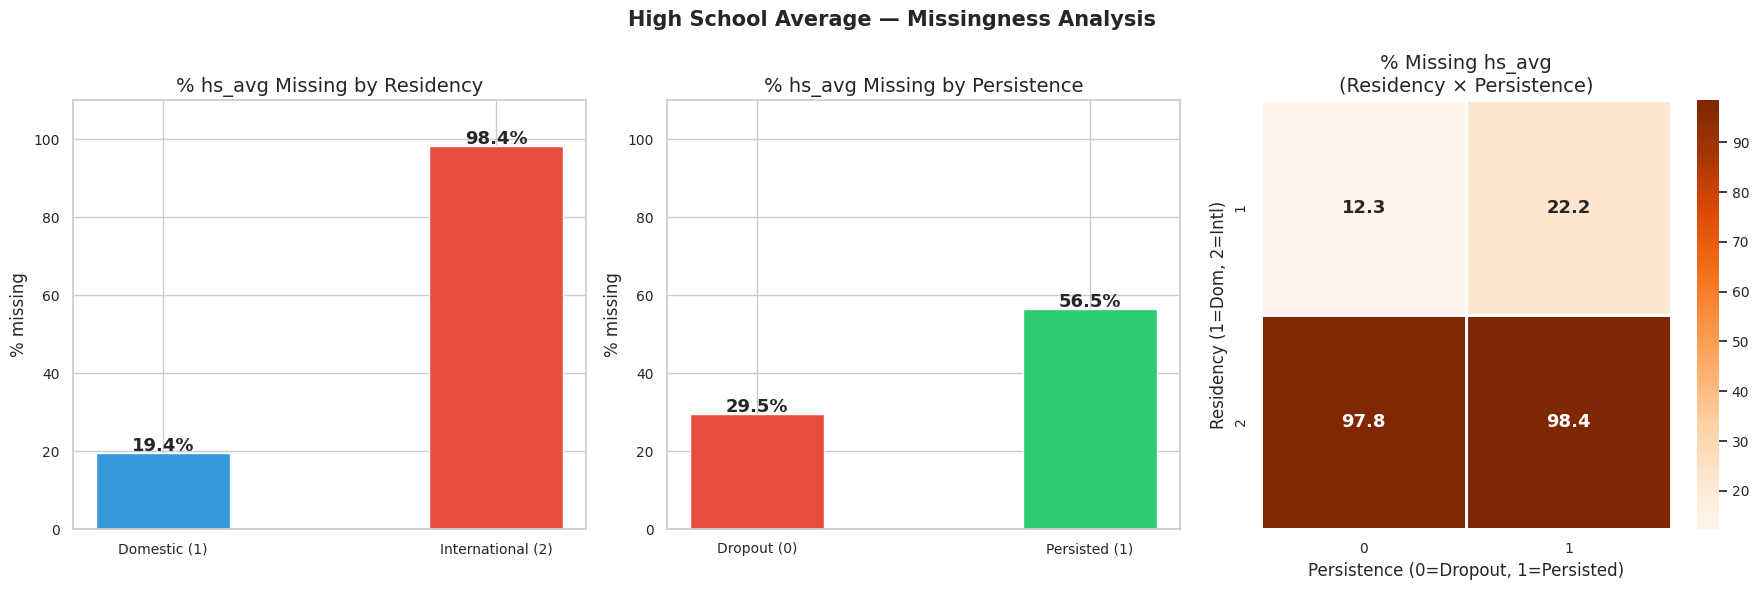

 Insight: International students have hs_avg missing at a MUCH higher rate.
 This is NOT random — international students studied in foreign systems.
 → KNN imputation is the right strategy (uses correlated features like GPA).


In [51]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 11 — HS Average Missing Data vs. Residency
# ─────────────────────────────────────────────────────────────────────────────

train_eda['hs_avg_missing'] = train_eda['hs_avg'].isnull().astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('High School Average — Missingness Analysis', fontsize=15, fontweight='bold')

miss_by_res = train_eda.groupby('residency')['hs_avg_missing'].mean() * 100
bars = axes[0].bar(
    ['Domestic (1)', 'International (2)'], miss_by_res.values,
    color=[CLR_NEUTRAL, CLR_DROPOUT], edgecolor='white', width=0.4
)
for bar, v in zip(bars, miss_by_res.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{v:.1f}%', ha='center', fontweight='bold', fontsize=13)
axes[0].set_title('% hs_avg Missing by Residency')
axes[0].set_ylabel('% missing')
axes[0].set_ylim(0, 110)

miss_by_per = train_eda.groupby('persistence')['hs_avg_missing'].mean() * 100
bars2 = axes[1].bar(
    ['Dropout (0)', 'Persisted (1)'], miss_by_per.values,
    color=[CLR_DROPOUT, CLR_PERSIST], edgecolor='white', width=0.4
)
for bar, v in zip(bars2, miss_by_per.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{v:.1f}%', ha='center', fontweight='bold', fontsize=13)
axes[1].set_title('% hs_avg Missing by Persistence')
axes[1].set_ylabel('% missing')
axes[1].set_ylim(0, 110)

pivot = train_eda.groupby(['residency', 'persistence'])['hs_avg_missing'].mean() * 100
pivot = pivot.unstack()
sns.heatmap(
    pivot, annot=True, fmt='.1f', cmap='Oranges',
    ax=axes[2], linewidths=1, annot_kws={'size': 13, 'fontweight': 'bold'}
)
axes[2].set_title('% Missing hs_avg\n(Residency × Persistence)')
axes[2].set_xlabel('Persistence (0=Dropout, 1=Persisted)')
axes[2].set_ylabel('Residency (1=Dom, 2=Intl)')

train_eda.drop(columns=['hs_avg_missing'], inplace=True)

plt.tight_layout()
plt.savefig('hs_avg_missing.png', dpi=150, bbox_inches='tight')
plt.show()

print(' Insight: International students have hs_avg missing at a MUCH higher rate.')
print(' This is NOT random — international students studied in foreign systems.')
print(' → KNN imputation is the right strategy (uses correlated features like GPA).')

---
## TRANSFORMATION SECTION

> Now we start actually cleaning and reshaping the data.  
> **All transformations are defined on training data and applied identically to val/test.**

### CELL 12 — Validate & Clip Features to Allowed Ranges

In [52]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 12 — Validate & Clip Features to Allowed Ranges
# ─────────────────────────────────────────────────────────────────────────────

VALID_RANGES = {
    'first_term_gpa' : (0.0, 4.5),
    'second_term_gpa': (0.0, 4.5),
    'hs_avg'         : (0.0, 100.0),
    'math_score'     : (0.0, 50.0),
    'first_language' : (1,   3),
    'funding'        : (1,   9),
    'fast_track'     : (1,   2),
    'coop'           : (1,   2),
    'residency'      : (1,   2),
    'gender'         : (1,   3),
    'prev_education' : (1,   2),
    'age_group'      : (1,  10),
    'english_grade'  : (1,  11),
}

def clip_ranges(frame, ranges=VALID_RANGES, label=''):
    out = frame.copy()
    print(f'\n  Clipping: {label}')
    for col, (lo, hi) in ranges.items():
        if col not in out.columns:
            continue
        n_out = ((out[col] < lo) | (out[col] > hi)).sum()
        out[col] = out[col].clip(lower=lo, upper=hi)
        if n_out > 0:
            print(f'    {col:<22}: clipped {n_out} value(s) to [{lo}, {hi}]')
    return out

X_train = clip_ranges(X_train, label='X_train')
X_val   = clip_ranges(X_val,   label='X_val')
X_test  = clip_ranges(X_test,  label='X_test')

print('\n All sets clipped to valid ranges.')


  Clipping: X_train
    hs_avg                : clipped 11 value(s) to [0.0, 100.0]
    prev_education        : clipped 65 value(s) to [1, 2]

  Clipping: X_val
    hs_avg                : clipped 1 value(s) to [0.0, 100.0]
    prev_education        : clipped 8 value(s) to [1, 2]

  Clipping: X_test
    hs_avg                : clipped 1 value(s) to [0.0, 100.0]
    prev_education        : clipped 15 value(s) to [1, 2]

 All sets clipped to valid ranges.


### CELL 13 — Drop Zero-Variance Features (School)

In [53]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 13 — Drop Zero-Variance & Useless Features
# ─────────────────────────────────────────────────────────────────────────────

print('Unique values per categorical column (training set):\n')
cat_check = ['school', 'funding', 'fast_track', 'coop', 'residency',
             'gender', 'first_language', 'prev_education', 'age_group']

cols_to_drop = []
for col in cat_check:
    if col not in X_train.columns:
        continue
    n_unique = X_train[col].nunique(dropna=True)
    vc = X_train[col].value_counts().to_dict()
    print(f'  {col:<22}: {n_unique} unique value(s) → {vc}')
    if n_unique <= 1:
        cols_to_drop.append(col)
        print(f'     Dropping — zero variance!')

if cols_to_drop:
    X_train.drop(columns=cols_to_drop, inplace=True)
    X_val.drop(  columns=cols_to_drop, inplace=True)
    X_test.drop( columns=cols_to_drop, inplace=True)
    print(f'\n Dropped: {cols_to_drop}')
else:
    print('\n No zero-variance columns found.')

print(f'\nRemaining features: {X_train.columns.tolist()}')

Unique values per categorical column (training set):

  school                : 1 unique value(s) → {6: 1077}
     Dropping — zero variance!
  funding               : 5 unique value(s) → {2: 603, 4: 422, 1: 24, 8: 21, 5: 7}
  fast_track            : 2 unique value(s) → {2: 809, 1: 268}
  coop                  : 2 unique value(s) → {2: 734, 1: 343}
  residency             : 2 unique value(s) → {1: 648, 2: 429}
  gender                : 3 unique value(s) → {2: 830, 1: 246, 3: 1}
  first_language        : 3 unique value(s) → {1.0: 564, 3.0: 433, 2.0: 2}
  prev_education        : 2 unique value(s) → {1.0: 716, 2.0: 361}
  age_group             : 8 unique value(s) → {3.0: 415, 1.0: 279, 2.0: 216, 4.0: 79, 5.0: 33, 7.0: 25, 6.0: 24, 8.0: 6}

 Dropped: ['school']

Remaining features: ['first_term_gpa', 'second_term_gpa', 'first_language', 'funding', 'fast_track', 'coop', 'residency', 'gender', 'prev_education', 'age_group', 'hs_avg', 'math_score', 'english_grade']


### CELL 14 — Feature Transformations (Language, Gender, GPA zeros)

In [54]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 14 — Feature Transformations
# ─────────────────────────────────────────────────────────────────────────────
# Three domain-specific decisions applied consistently to all splits:
#
#  A) first_language: merge French (2) and Other (3) → both become 2
#     Reason: only 4 out of 1437 students are French → statistically unreliable
#
#  B) gender: value 3 (Neutral, only 1 student) → treat as NaN
#     Reason: cannot learn from a single example; will be imputed with mode
#
#  C) first_term_gpa = 0 AND second_term_gpa ≠ 0 → treat as NaN
#     Reason: a student with GPA=0 who has a second-term GPA likely just had
#     their first-term mark not recorded (administrative zero, not academic zero)

def apply_feature_transforms(frame):
    out = frame.copy()

    if 'first_language' in out.columns:
        out['first_language'] = out['first_language'].replace(3, 2)

    if 'gender' in out.columns:
        out['gender'] = out['gender'].replace(3, np.nan)

    if 'first_term_gpa' in out.columns and 'second_term_gpa' in out.columns:
        mask = (out['first_term_gpa'] == 0) & (out['second_term_gpa'] != 0)
        n_zeroed = mask.sum()
        out.loc[mask, 'first_term_gpa'] = np.nan
        if n_zeroed > 0:
            print(f'    first_term_gpa: {n_zeroed} administrative zero(s) → NaN')

    return out

print('Applying transforms...')
X_train = apply_feature_transforms(X_train)
X_val   = apply_feature_transforms(X_val)
X_test  = apply_feature_transforms(X_test)

print('\n  first_language value counts after merge (train):')
print(f'    {X_train["first_language"].value_counts().to_dict()}')
print('\n  gender unique values after transform (train):')
print(f'    {X_train["gender"].value_counts(dropna=False).to_dict()}')

print('\n Transforms applied to train, val, and test.')

Applying transforms...
    first_term_gpa: 42 administrative zero(s) → NaN
    first_term_gpa: 8 administrative zero(s) → NaN
    first_term_gpa: 8 administrative zero(s) → NaN

  first_language value counts after merge (train):
    {1.0: 564, 2.0: 435}

  gender unique values after transform (train):
    {2.0: 830, 1.0: 246, nan: 1}

 Transforms applied to train, val, and test.


### CELL 15 — Create hs_avg_miss_flag

In [55]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 15 — Create hs_avg_miss_flag
# ─────────────────────────────────────────────────────────────────────────────

for X in [X_train, X_val, X_test]:
    X['hs_avg_miss_flag'] = X['hs_avg'].isnull().astype(int)

print('hs_avg_miss_flag created.')
print(f'  Train — flag=1 (missing): {X_train["hs_avg_miss_flag"].sum()}')
print(f'          flag=0 (present): {(X_train["hs_avg_miss_flag"]==0).sum()}')

print('\n Flag column added to all three splits.')

hs_avg_miss_flag created.
  Train — flag=1 (missing): 548
          flag=0 (present): 529

 Flag column added to all three splits.


---
## IMPUTATION SECTION

### CELL 16 — Impute first_language from Residency

In [56]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 16 — Impute first_language Using Residency as Reference
# ─────────────────────────────────────────────────────────────────────────────

def impute_language_from_residency(frame):
    out = frame.copy()
    mask = out['first_language'].isnull()
    n_before = mask.sum()
    if n_before == 0:
        print('    No missing values in first_language.')
        return out
    # Rule: domestic → 1, international → 2
    out.loc[mask & (out['residency'] == 1), 'first_language'] = 1
    out.loc[mask & (out['residency'] == 2), 'first_language'] = 2
    n_after = out['first_language'].isnull().sum()
    print(f'    Imputed {n_before - n_after} missing first_language values  '
          f'({n_after} remain)')
    return out

print('Imputing first_language...')
X_train = impute_language_from_residency(X_train)
X_val   = impute_language_from_residency(X_val)
X_test  = impute_language_from_residency(X_test)

print('\n first_language fully imputed.')

Imputing first_language...
    Imputed 78 missing first_language values  (0 remain)
    Imputed 16 missing first_language values  (0 remain)
    Imputed 17 missing first_language values  (0 remain)

 first_language fully imputed.


### CELL 17 — Group-Wise Median Imputation (GPA & Math Score)

In [57]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 17 — Group-Wise Median Imputation for GPA & Math Score
# ─────────────────────────────────────────────────────────────────────────────
# Key insight: students who persist have HIGHER GPA on average.
# If we impute a single global median we push dropout students' GPA upward.
# Solution: compute the median SEPARATELY for each persistence group
#           and impute using the group the student belongs to.
#
# IMPORTANT: medians are computed from TRAINING data only,
#            then applied to val/test (no leakage).

GW_COLS = ['first_term_gpa', 'second_term_gpa', 'math_score']

gw_medians = {}
train_with_target = X_train.copy()
train_with_target['persistence'] = y_train.values

print('Group-wise medians (training data):')
for col in GW_COLS:
    med_persist = train_with_target[train_with_target['persistence']==1][col].median()
    med_dropout = train_with_target[train_with_target['persistence']==0][col].median()
    gw_medians[col] = {1: med_persist, 0: med_dropout}
    print(f'  {col:<22}: persist={med_persist:.3f}  dropout={med_dropout:.3f}')

def group_median_impute(X, y_labels, medians):
    out = X.copy()
    for col, group_meds in medians.items():
        if col not in out.columns:
            continue
        for label, med in group_meds.items():
            mask = out[col].isnull() & (y_labels.values == label)
            out.loc[mask, col] = med

        global_med = train_with_target[col].median()
        out[col].fillna(global_med, inplace=True)
    return out

X_train = group_median_impute(X_train, y_train, gw_medians)
X_val   = group_median_impute(X_val,   y_val,   gw_medians)
X_test  = group_median_impute(X_test,  y_test,  gw_medians)

print('\nMissing values after group-wise imputation:')
print(X_train[GW_COLS].isnull().sum().to_string())
print('\n GPA and Math Score fully imputed.')

Group-wise medians (training data):
  first_term_gpa        : persist=3.312  dropout=1.745
  second_term_gpa       : persist=3.125  dropout=1.229
  math_score            : persist=34.000  dropout=26.000

Missing values after group-wise imputation:
first_term_gpa     0
second_term_gpa    0
math_score         0

 GPA and Math Score fully imputed.


### CELL 18 — Mode Imputation (Gender, Prev Education, Age Group, English Grade)

In [58]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 18 — Mode Imputation for Categorical/Ordinal Features
# ─────────────────────────────────────────────────────────────────────────────
# Features:
#   gender
#   prev_education
#   age_group
#   english_grade

MODE_COLS = ['gender', 'prev_education', 'age_group', 'english_grade']

train_modes = {col: X_train[col].mode()[0] for col in MODE_COLS if col in X_train.columns}

print('Modes computed from training data:')
for col, mode in train_modes.items():
    print(f'  {col:<22}: {mode}')

def mode_impute(frame, modes):
    out = frame.copy()
    for col, mode in modes.items():
        if col not in out.columns:
            continue
        n_missing = out[col].isnull().sum()
        out[col].fillna(mode, inplace=True)
        if n_missing > 0:
            print(f'    {col}: filled {n_missing} NaN with mode={mode}')
    return out

print('\nApplying mode imputation...')
X_train = mode_impute(X_train, train_modes)
X_val   = mode_impute(X_val,   train_modes)
X_test  = mode_impute(X_test,  train_modes)

print('\nRemaining missing values (should be only hs_avg):')
remaining = X_train.isnull().sum()
print(remaining[remaining > 0])
print('\n Categorical columns fully imputed.')

Modes computed from training data:
  gender                : 2.0
  prev_education        : 1.0
  age_group             : 3.0
  english_grade         : 9.0

Applying mode imputation...
    gender: filled 1 NaN with mode=2.0
    english_grade: filled 30 NaN with mode=9.0
    prev_education: filled 2 NaN with mode=1.0
    age_group: filled 2 NaN with mode=3.0
    english_grade: filled 10 NaN with mode=9.0
    prev_education: filled 2 NaN with mode=1.0
    age_group: filled 2 NaN with mode=3.0
    english_grade: filled 5 NaN with mode=9.0

Remaining missing values (should be only hs_avg):
hs_avg    548
dtype: int64

 Categorical columns fully imputed.


---
## SCALING SECTION

### CELL 19 — Binary Re-Coding (1/2 → 0/1)

In [59]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 19 — Binary Re-Coding  (1/2 → 0/1)
# ─────────────────────────────────────────────────────────────────────────────
# Affected columns:
#   first_language, fast_track, coop, residency, gender, prev_education

BINARY_RECODE = ['first_language', 'fast_track', 'coop',
                 'residency', 'gender', 'prev_education']

def recode_binary(frame, cols):
    out = frame.copy()
    for col in cols:
        if col not in out.columns:
            continue
        out[col] = out[col] - 1
    return out

X_train = recode_binary(X_train, BINARY_RECODE)
X_val   = recode_binary(X_val,   BINARY_RECODE)
X_test  = recode_binary(X_test,  BINARY_RECODE)

print('Binary re-coding complete.')
print('Sample values after recode (train):')
for col in BINARY_RECODE:
    if col in X_train.columns:
        print(f'  {col:<22}: {sorted(X_train[col].unique())}')

print('\n All binary columns are now 0/1.')

Binary re-coding complete.
Sample values after recode (train):
  first_language        : [np.float64(0.0), np.float64(1.0)]
  fast_track            : [np.int64(0), np.int64(1)]
  coop                  : [np.int64(0), np.int64(1)]
  residency             : [np.int64(0), np.int64(1)]
  gender                : [np.float64(0.0), np.float64(1.0)]
  prev_education        : [np.float64(0.0), np.float64(1.0)]

 All binary columns are now 0/1.


### CELL 20 — One-Hot Encoding (Funding)

In [60]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 20 — One-Hot Encoding for Funding
# ─────────────────────────────────────────────────────────────────────────────
# Funding

from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', dtype=np.float32)

ohe.fit(X_train[['funding']])
funding_categories = ohe.get_feature_names_out(['funding'])
print(f'OHE categories learned from training: {funding_categories}')

def apply_ohe(frame, encoder, col, new_cols):
    out = frame.copy()
    encoded = encoder.transform(out[[col]])
    encoded_df = pd.DataFrame(encoded, columns=new_cols, index=out.index)
    out = pd.concat([out.drop(columns=[col]), encoded_df], axis=1)
    return out

X_train = apply_ohe(X_train, ohe, 'funding', funding_categories)
X_val   = apply_ohe(X_val,   ohe, 'funding', funding_categories)
X_test  = apply_ohe(X_test,  ohe, 'funding', funding_categories)

print(f'\nNew funding columns: {funding_categories.tolist()}')
print(f'X_train shape after OHE: {X_train.shape}')
print('\n One-Hot Encoding applied to Funding.')

OHE categories learned from training: ['funding_1' 'funding_2' 'funding_4' 'funding_5' 'funding_8']

New funding columns: ['funding_1', 'funding_2', 'funding_4', 'funding_5', 'funding_8']
X_train shape after OHE: (1077, 18)

 One-Hot Encoding applied to Funding.


### CELL 21 — StandardScaler (Continuous & Ordinal Features)

In [61]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 21 — StandardScaler for Continuous & Ordinal Features
# ─────────────────────────────────────────────────────────────────────────────
# Columns to scale:
# first_term_gpa, second_term_gpa, age_group, hs_avg, math_score, english_grade

SCALE_COLS = ['first_term_gpa', 'second_term_gpa', 'age_group',
              'hs_avg', 'math_score', 'english_grade']

scaler = StandardScaler()
scaler.fit(X_train[SCALE_COLS])

for X in [X_train, X_val, X_test]:
    X[SCALE_COLS] = scaler.transform(X[SCALE_COLS])

print('StandardScaler fitted on training data.')
print('\nMeans and std learned from training:')
for col, mean, std in zip(SCALE_COLS, scaler.mean_, scaler.scale_):
    print(f'  {col:<22}: mean={mean:>8.3f}  std={std:>6.3f}')

print(f'\nRemaining NaN after scaling (should be only hs_avg):')
remaining = X_train.isnull().sum()
print(remaining[remaining > 0])
print('\n Scaling complete. hs_avg NaN preserved for KNN next step.')

StandardScaler fitted on training data.

Means and std learned from training:
  first_term_gpa        : mean=   2.877  std= 1.079
  second_term_gpa       : mean=   2.623  std= 1.200
  age_group             : mean=   2.604  std= 1.410
  hs_avg                : mean=  76.974  std=12.024
  math_score            : mean=  32.617  std= 9.053
  english_grade         : mean=   8.071  std= 1.706

Remaining NaN after scaling (should be only hs_avg):
hs_avg    548
dtype: int64

 Scaling complete. hs_avg NaN preserved for KNN next step.


### CELL 22 — KNN Imputation for hs_avg (on Scaled Data)

In [62]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 22 — KNN Imputation for hs_avg
# ─────────────────────────────────────────────────────────────────────────────

N_NEIGHBORS = 5

knn_imputer = KNNImputer(n_neighbors=N_NEIGHBORS)

cols_for_knn = X_train.columns.tolist()

knn_imputer.fit(X_train[cols_for_knn])

X_train[cols_for_knn] = knn_imputer.transform(X_train[cols_for_knn])
X_val[cols_for_knn]   = knn_imputer.transform(X_val[cols_for_knn])
X_test[cols_for_knn]  = knn_imputer.transform(X_test[cols_for_knn])

print(f'KNN imputation complete (K={N_NEIGHBORS})')
print('\nMissing values after KNN:')
remaining = X_train.isnull().sum()
if remaining.sum() == 0:
    print('  None! Dataset is 100% complete')
else:
    print(remaining[remaining > 0])

print(f'\nFinal X_train shape: {X_train.shape}')
print(f'Final X_val   shape: {X_val.shape}')
print(f'Final X_test  shape: {X_test.shape}')
print('\n KNN imputation done. hs_avg is now imputed AND scaled.')

KNN imputation complete (K=5)

Missing values after KNN:
  None! Dataset is 100% complete

Final X_train shape: (1077, 18)
Final X_val   shape: (144, 18)
Final X_test  shape: (216, 18)

 KNN imputation done. hs_avg is now imputed AND scaled.


### CELL 23 — Create program_completion Feature

In [63]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 23 — Create Engineered Feature: program_completion
# ─────────────────────────────────────────────────────────────────────────────
# Business rule (Scale after):
#   program_completion = 1  if  (first_term_gpa + second_term_gpa) / 2 >= 2.0
#                       = 0  otherwise

gpa_cols_idx   = [SCALE_COLS.index(c) for c in ['first_term_gpa', 'second_term_gpa']]
threshold_orig = 2.0
threshold_scaled_1 = (threshold_orig - scaler.mean_[gpa_cols_idx[0]]) / scaler.scale_[gpa_cols_idx[0]]
threshold_scaled_2 = (threshold_orig - scaler.mean_[gpa_cols_idx[1]]) / scaler.scale_[gpa_cols_idx[1]]
threshold_avg_scaled = (threshold_scaled_1 + threshold_scaled_2) / 2

def add_program_completion(frame):
    out = frame.copy()
    avg_gpa = (out['first_term_gpa'] + out['second_term_gpa']) / 2
    out['program_completion'] = (avg_gpa >= threshold_avg_scaled).astype(int)
    return out

X_train = add_program_completion(X_train)
X_val   = add_program_completion(X_val)
X_test  = add_program_completion(X_test)

print(f'program_completion threshold in scaled space: {threshold_avg_scaled:.4f}')
print(f'  (equivalent to average GPA ≥ 2.0 in original space)')
print(f'\nTrain — program_completion=1: {X_train["program_completion"].sum()} students')
print(f'Train — program_completion=0: {(X_train["program_completion"]==0).sum()} students')
print('\n Program_completion feature added to all splits.')

program_completion threshold in scaled space: -0.6656
  (equivalent to average GPA ≥ 2.0 in original space)

Train — program_completion=1: 806 students
Train — program_completion=0: 271 students

 Program_completion feature added to all splits.


---
## CELL 24 — Pipeline Summary & Final Sanity Check

In [64]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 24 — Pipeline Summary & Final Sanity Check
# ─────────────────────────────────────────────────────────────────────────────

import joblib

print('═' * 60)
print('  PREPROCESSING PIPELINE — COMPLETE SUMMARY')
print('═' * 60)

for name, X, y in [('TRAIN', X_train, y_train),
                    ('VAL  ', X_val,   y_val),
                    ('TEST ', X_test,  y_test)]:
    n_nan  = X.isnull().sum().sum()
    print(f'\n  {name}  |  shape={X.shape}  |  NaN={n_nan}  |  '
          f'persist={y.mean():.2%}  dropout={1-y.mean():.2%}')
    if n_nan > 0:
        print(f'   Missing columns: {X.columns[X.isnull().any()].tolist()}')

print(f'\n  Final feature list ({X_train.shape[1]} features):')
for i, col in enumerate(X_train.columns, 1):
    print(f'    {i:>2}. {col}')

print('\n')
print('─' * 60)
print('\n  SAVING preprocessing artefacts...')
joblib.dump(scaler,       'scaler.pkl')
joblib.dump(ohe,          'ohe_funding.pkl')
joblib.dump(knn_imputer,  'knn_imputer.pkl')
joblib.dump(gw_medians,   'group_medians.pkl')
joblib.dump(train_modes,  'train_modes.pkl')
print('  Saved: scaler.pkl, ohe_funding.pkl, knn_imputer.pkl,')
print('           group_medians.pkl, train_modes.pkl')

print('\n')
print('─' * 60)
print('\n  Preprocessing pipeline COMPLETE!')
print('  Next step → Model Training (TensorFlow / Keras)')
print('═' * 60)

════════════════════════════════════════════════════════════
  PREPROCESSING PIPELINE — COMPLETE SUMMARY
════════════════════════════════════════════════════════════

  TRAIN  |  shape=(1077, 19)  |  NaN=0  |  persist=79.20%  dropout=20.80%

  VAL    |  shape=(144, 19)  |  NaN=0  |  persist=79.17%  dropout=20.83%

  TEST   |  shape=(216, 19)  |  NaN=0  |  persist=79.17%  dropout=20.83%

  Final feature list (19 features):
     1. first_term_gpa
     2. second_term_gpa
     3. first_language
     4. fast_track
     5. coop
     6. residency
     7. gender
     8. prev_education
     9. age_group
    10. hs_avg
    11. math_score
    12. english_grade
    13. hs_avg_miss_flag
    14. funding_1
    15. funding_2
    16. funding_4
    17. funding_5
    18. funding_8
    19. program_completion


────────────────────────────────────────────────────────────

  SAVING preprocessing artefacts...
  Saved: scaler.pkl, ohe_funding.pkl, knn_imputer.pkl,
           group_medians.pkl, train_modes.pkl

---
## EXPERIMENT SECTION

> Before committing to one architecture, we run a **systematic experiment grid**
> across 32 configurations — varying layers, neurons, activations, optimizers,
> dropout rates, and batch sizes.
>
> **Each experiment is evaluated on the validation set.**
>
> Results are collected in a DataFrame and visualised in a ranked comparison table.

### CELL 25 — Define Experiment Grid (32 configurations)

In [65]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 25 — Define the Experiment Grid
# ─────────────────────────────────────────────────────────────────────────────
# We explore 5 dimensions systematically:
#
#   A) Depth          — 1, 2, 3 hidden layers
#   B) Width          — 64, 128, 256 neurons
#   C) Activation     — ReLU, ELU, Tanh, SELU
#   D) Optimizer      — Adam, AdamW, RMSprop, SGD
#   E) Regularization — Dropout 0.3, 0.5, BatchNorm on/off
#   F) Batch size     — 16, 32, 64
#
# Every experiment uses:
#   - class_weight to handle imbalance
#   - EarlyStopping (patience=20, restore_best_weights=True)
#   - ReduceLROnPlateau (patience=10)
#   - max 150 epochs
#
# Primary ranking metric: F1-score for Dropout class (class 0)
# Secondary metric: AUC-ROC

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import numpy as np
import pandas as pd
import time
from sklearn.metrics import f1_score, roc_auc_score, classification_report
from sklearn.utils.class_weight import compute_class_weight

tf.random.set_seed(42)
np.random.seed(42)

X_train_np = X_train.values.astype(np.float32)
X_val_np   = X_val.values.astype(np.float32)
y_train_np = y_train.values.astype(np.float32)
y_val_np   = y_val.values.astype(np.float32)

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes.astype(int), weights))

n_features = X_train_np.shape[1]

# ── Experiment definitions ────────────────────────────────────────────────
EXPERIMENTS = [
    # A) Depth experiments (1-layer baselines)
    {'name': '1L-64-ReLU-Adam',          'layers': [64],         'act': 'relu',    'opt': 'adam',   'drop': 0.3, 'bn': True,  'bs': 32, 'lr': 1e-3},
    {'name': '1L-128-ReLU-Adam',         'layers': [128],        'act': 'relu',    'opt': 'adam',   'drop': 0.3, 'bn': True,  'bs': 32, 'lr': 1e-3},
    {'name': '1L-256-ReLU-Adam',         'layers': [256],        'act': 'relu',    'opt': 'adam',   'drop': 0.3, 'bn': True,  'bs': 32, 'lr': 1e-3},
    # B) 2-layer architectures — width variation
    {'name': '2L-64-32-ReLU-Adam',       'layers': [64, 32],     'act': 'relu',    'opt': 'adam',   'drop': 0.3, 'bn': True,  'bs': 32, 'lr': 1e-3},
    {'name': '2L-128-64-ReLU-Adam',      'layers': [128, 64],    'act': 'relu',    'opt': 'adam',   'drop': 0.3, 'bn': True,  'bs': 32, 'lr': 1e-3},
    {'name': '2L-256-128-ReLU-Adam',     'layers': [256, 128],   'act': 'relu',    'opt': 'adam',   'drop': 0.3, 'bn': True,  'bs': 32, 'lr': 1e-3},
    {'name': '2L-256-64-ReLU-Adam',      'layers': [256, 64],    'act': 'relu',    'opt': 'adam',   'drop': 0.3, 'bn': True,  'bs': 32, 'lr': 1e-3},
    # C) 3-layer architectures
    {'name': '3L-128-64-32-ReLU-Adam',   'layers': [128, 64, 32],'act': 'relu',    'opt': 'adam',   'drop': 0.3, 'bn': True,  'bs': 32, 'lr': 1e-3},
    {'name': '3L-256-128-64-ReLU-Adam',  'layers': [256,128, 64],'act': 'relu',    'opt': 'adam',   'drop': 0.3, 'bn': True,  'bs': 32, 'lr': 1e-3},
    {'name': '3L-512-256-128-ReLU-Adam', 'layers': [512,256,128],'act': 'relu',    'opt': 'adam',   'drop': 0.3, 'bn': True,  'bs': 32, 'lr': 1e-3},
    # D) Activation functions (fixed 2L-128-64)
    {'name': '2L-128-64-Tanh-Adam',      'layers': [128, 64],    'act': 'tanh',    'opt': 'adam',   'drop': 0.3, 'bn': True,  'bs': 32, 'lr': 1e-3},
    {'name': '2L-128-64-ELU-Adam',       'layers': [128, 64],    'act': 'elu',     'opt': 'adam',   'drop': 0.3, 'bn': True,  'bs': 32, 'lr': 1e-3},
    {'name': '2L-128-64-SELU-Adam',      'layers': [128, 64],    'act': 'selu',    'opt': 'adam',   'drop': 0.3, 'bn': False, 'bs': 32, 'lr': 1e-3},
    {'name': '2L-128-64-LeakyReLU-Adam', 'layers': [128, 64],    'act': 'lrelu',   'opt': 'adam',   'drop': 0.3, 'bn': True,  'bs': 32, 'lr': 1e-3},
    # E) Optimizers (fixed 2L-128-64-ReLU)
    {'name': '2L-128-64-ReLU-AdamW',     'layers': [128, 64],    'act': 'relu',    'opt': 'adamw',  'drop': 0.3, 'bn': True,  'bs': 32, 'lr': 1e-3},
    {'name': '2L-128-64-ReLU-RMSprop',   'layers': [128, 64],    'act': 'relu',    'opt': 'rmsprop','drop': 0.3, 'bn': True,  'bs': 32, 'lr': 1e-3},
    {'name': '2L-128-64-ReLU-SGD',       'layers': [128, 64],    'act': 'relu',    'opt': 'sgd',    'drop': 0.3, 'bn': True,  'bs': 32, 'lr': 1e-2},
    {'name': '2L-128-64-ReLU-Adamax',    'layers': [128, 64],    'act': 'relu',    'opt': 'adamax', 'drop': 0.3, 'bn': True,  'bs': 32, 'lr': 1e-3},
    # F) Dropout rates
    {'name': '2L-128-64-Drop0.1',        'layers': [128, 64],    'act': 'relu',    'opt': 'adam',   'drop': 0.1, 'bn': True,  'bs': 32, 'lr': 1e-3},
    {'name': '2L-128-64-Drop0.2',        'layers': [128, 64],    'act': 'relu',    'opt': 'adam',   'drop': 0.2, 'bn': True,  'bs': 32, 'lr': 1e-3},
    {'name': '2L-128-64-Drop0.4',        'layers': [128, 64],    'act': 'relu',    'opt': 'adam',   'drop': 0.4, 'bn': True,  'bs': 32, 'lr': 1e-3},
    {'name': '2L-128-64-Drop0.5',        'layers': [128, 64],    'act': 'relu',    'opt': 'adam',   'drop': 0.5, 'bn': True,  'bs': 32, 'lr': 1e-3},
    # G) BatchNorm on vs off
    {'name': '2L-128-64-NoBN',           'layers': [128, 64],    'act': 'relu',    'opt': 'adam',   'drop': 0.3, 'bn': False, 'bs': 32, 'lr': 1e-3},
    # H) Batch sizes
    {'name': '2L-128-64-Batch16',        'layers': [128, 64],    'act': 'relu',    'opt': 'adam',   'drop': 0.3, 'bn': True,  'bs': 16, 'lr': 1e-3},
    {'name': '2L-128-64-Batch64',        'layers': [128, 64],    'act': 'relu',    'opt': 'adam',   'drop': 0.3, 'bn': True,  'bs': 64, 'lr': 1e-3},
    {'name': '2L-128-64-Batch128',       'layers': [128, 64],    'act': 'relu',    'opt': 'adam',   'drop': 0.3, 'bn': True,  'bs':128, 'lr': 1e-3},
    # I) Learning rate variants
    {'name': '2L-128-64-LR0.01',         'layers': [128, 64],    'act': 'relu',    'opt': 'adam',   'drop': 0.3, 'bn': True,  'bs': 32, 'lr': 1e-2},
    {'name': '2L-128-64-LR0.0001',       'layers': [128, 64],    'act': 'relu',    'opt': 'adam',   'drop': 0.3, 'bn': True,  'bs': 32, 'lr': 1e-4},
    # J) L2 regularization strength
    {'name': '2L-128-64-L2-1e3',         'layers': [128, 64],    'act': 'relu',    'opt': 'adam',   'drop': 0.3, 'bn': True,  'bs': 32, 'lr': 1e-3, 'l2': 1e-3},
    {'name': '2L-128-64-L2-1e5',         'layers': [128, 64],    'act': 'relu',    'opt': 'adam',   'drop': 0.3, 'bn': True,  'bs': 32, 'lr': 1e-3, 'l2': 1e-5},
    # K) No class weight (baseline comparison)
    {'name': '2L-128-64-NoClassWeight',  'layers': [128, 64],    'act': 'relu',    'opt': 'adam',   'drop': 0.3, 'bn': True,  'bs': 32, 'lr': 1e-3, 'no_cw': True},
    # L) Wide & shallow vs narrow & deep
    {'name': '1L-512-ReLU-Adam',         'layers': [512],        'act': 'relu',    'opt': 'adam',   'drop': 0.4, 'bn': True,  'bs': 32, 'lr': 1e-3},
]

print(f'Total experiments defined: {len(EXPERIMENTS)}')
print('Dimensions explored:')
print('  Depth         : 1, 2, 3 layers')
print('  Width         : 32, 64, 128, 256, 512 neurons')
print('  Activations   : ReLU, ELU, Tanh, SELU, LeakyReLU')
print('  Optimizers    : Adam, AdamW, RMSprop, SGD, Adamax')
print('  Dropout rates : 0.1, 0.2, 0.3, 0.4, 0.5')
print('  Batch sizes   : 16, 32, 64, 128')
print('  Learning rates: 0.01, 0.001, 0.0001')
print('  L2 strength   : 1e-3, 1e-4, 1e-5')
print('  BatchNorm     : on vs off')
print('  Class weight  : balanced vs none')


Total experiments defined: 32
Dimensions explored:
  Depth         : 1, 2, 3 layers
  Width         : 32, 64, 128, 256, 512 neurons
  Activations   : ReLU, ELU, Tanh, SELU, LeakyReLU
  Optimizers    : Adam, AdamW, RMSprop, SGD, Adamax
  Dropout rates : 0.1, 0.2, 0.3, 0.4, 0.5
  Batch sizes   : 16, 32, 64, 128
  Learning rates: 0.01, 0.001, 0.0001
  L2 strength   : 1e-3, 1e-4, 1e-5
  BatchNorm     : on vs off
  Class weight  : balanced vs none


### CELL 26 — Build Model Factory + Run All Experiments

In [66]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 26 — Model Factory + Experiment Runner
# ─────────────────────────────────────────────────────────────────────────────

def get_activation(name):
    if name == 'lrelu':
        return layers.LeakyReLU(negative_slope=0.1)
    return name

def get_optimizer(name, lr, l2_val=1e-4):
    opts = {
        'adam':    keras.optimizers.Adam(lr),
        'adamw':   keras.optimizers.AdamW(lr, weight_decay=l2_val),
        'rmsprop': keras.optimizers.RMSprop(lr),
        'sgd':     keras.optimizers.SGD(lr, momentum=0.9, nesterov=True),
        'adamax':  keras.optimizers.Adamax(lr),
    }
    return opts[name]

def build_experiment_model(cfg, n_features):
    l2_val = cfg.get('l2', 1e-4)
    inp = keras.Input(shape=(n_features,))
    x   = inp
    for i, units in enumerate(cfg['layers']):
        act = get_activation(cfg['act'])
        x = layers.Dense(units, kernel_regularizer=regularizers.l2(l2_val))(x)
        if cfg['bn'] and cfg['act'] != 'selu':
            x = layers.BatchNormalization()(x)
        if isinstance(act, str):
            x = layers.Activation(act)(x)
        else:
            x = act(x)
        drop_rate = cfg['drop'] - i * 0.05
        x = layers.Dropout(max(drop_rate, 0.1))(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    model = keras.Model(inp, out)
    model.compile(
        optimizer=get_optimizer(cfg['opt'], cfg['lr'], l2_val),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc'),
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')]
    )
    return model

def run_experiments(experiments, X_tr, y_tr, X_vl, y_vl, cw_dict):
    results = []
    n = len(experiments)
    for i, cfg in enumerate(experiments):
        print(f'  [{i+1:>2}/{n}]  {cfg["name"]:<40}', end=' ')
        t0 = time.time()
        tf.keras.backend.clear_session()
        tf.random.set_seed(42)
        model = build_experiment_model(cfg, n_features)
        cbs = [
            keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=20,
                restore_best_weights=True, verbose=0
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5,
                patience=10, min_lr=1e-6, verbose=0
            ),
        ]
        cw = None if cfg.get('no_cw') else cw_dict
        hist = model.fit(
            X_tr, y_tr,
            validation_data=(X_vl, y_vl),
            epochs=150, batch_size=cfg['bs'],
            class_weight=cw, callbacks=cbs, verbose=0
        )
        t1   = time.time()
        ep   = np.argmin(hist.history['val_loss']) + 1
        t_acc = hist.history['accuracy'][ep-1]
        v_acc = hist.history['val_accuracy'][ep-1]
        v_auc = hist.history['val_auc'][ep-1]
        v_pre = hist.history['val_precision'][ep-1]
        v_rec = hist.history['val_recall'][ep-1]
        y_prob = model.predict(X_vl, verbose=0).flatten()
        y_pred = (y_prob >= 0.5).astype(int)
        f1_0 = f1_score(y_vl, y_pred, pos_label=0, zero_division=0)
        f1_1 = f1_score(y_vl, y_pred, pos_label=1, zero_division=0)
        gap  = abs(t_acc - v_acc)
        row = {
            'experiment'    : cfg['name'],
            'train_acc'     : round(t_acc * 100, 2),
            'val_acc'       : round(v_acc * 100, 2),
            'val_auc'       : round(v_auc * 100, 2),
            'val_precision' : round(v_pre * 100, 2),
            'val_recall'    : round(v_rec * 100, 2),
            'f1_dropout'    : round(f1_0 * 100, 2),
            'f1_persist'    : round(f1_1 * 100, 2),
            'gap'           : round(gap * 100, 2),
            'epochs'        : ep,
            'time_s'        : round(t1 - t0, 1),
        }
        results.append(row)
        print(f'val_acc={v_acc:.3f}  f1_drop={f1_0:.3f}  auc={v_auc:.3f}  '
              f'ep={ep}  {t1-t0:.1f}s')
    return pd.DataFrame(results)

print('Starting experiment run...')
print('=' * 70)
results_df = run_experiments(
    EXPERIMENTS, X_train_np, y_train_np, X_val_np, y_val_np, class_weight_dict
)
print('=' * 70)
print(f'All {len(results_df)} experiments complete!')


Starting experiment run...
  [ 1/32]  1L-64-ReLU-Adam                          val_acc=0.882  f1_drop=0.721  auc=0.929  ep=51  23.9s
  [ 2/32]  1L-128-ReLU-Adam                         val_acc=0.861  f1_drop=0.677  auc=0.899  ep=61  25.3s
  [ 3/32]  1L-256-ReLU-Adam                         val_acc=0.854  f1_drop=0.656  auc=0.905  ep=40  20.6s
  [ 4/32]  2L-64-32-ReLU-Adam                       val_acc=0.889  f1_drop=0.742  auc=0.935  ep=60  28.7s
  [ 5/32]  2L-128-64-ReLU-Adam                      val_acc=0.896  f1_drop=0.754  auc=0.939  ep=72  31.6s
  [ 6/32]  2L-256-128-ReLU-Adam                     val_acc=0.875  f1_drop=0.710  auc=0.912  ep=19  18.6s
  [ 7/32]  2L-256-64-ReLU-Adam                      val_acc=0.896  f1_drop=0.762  auc=0.933  ep=47  25.6s
  [ 8/32]  3L-128-64-32-ReLU-Adam                   val_acc=0.875  f1_drop=0.710  auc=0.925  ep=56  31.5s
  [ 9/32]  3L-256-128-64-ReLU-Adam                  val_acc=0.882  f1_drop=0.721  auc=0.928  ep=21  22.4s
  [10/32]  3L-512-2

### CELL 27 — Results Table + Visual Comparison

  EXPERIMENT RESULTS  (ranked by F1-dropout, val set, threshold=0.50)
  #  Experiment                              TrainAcc   ValAcc     AUC  F1-drop  F1-per    Gap   Ep   Time
-----------------------------------------------------------------------------------------------
  1  2L-128-64-L2-1e5                          89.88%   90.28%  92.87%   77.42%  93.81%  0.40%   54  27.3s <-- BEST
  2  2L-128-64-ReLU-AdamW                      88.58%   90.28%  92.50%   76.67%  93.86%  1.70%   48  26.0s
  3  2L-256-64-ReLU-Adam                       91.27%   89.58%  93.35%   76.19%  93.33%  1.69%   47  25.6s
  4  2L-128-64-LeakyReLU-Adam                  86.54%   88.89%  92.12%   75.76%  92.79%  2.35%   38  23.7s
  5  2L-128-64-ReLU-Adam                       91.18%   89.58%  93.92%   75.41%  93.39%  1.60%   72  31.6s
  6  2L-64-32-ReLU-Adam                        86.54%   88.89%  93.48%   74.19%  92.92%  2.35%   60  28.7s
  7  2L-128-64-LR0.01                          92.57%   88.89%  93.35%   74.

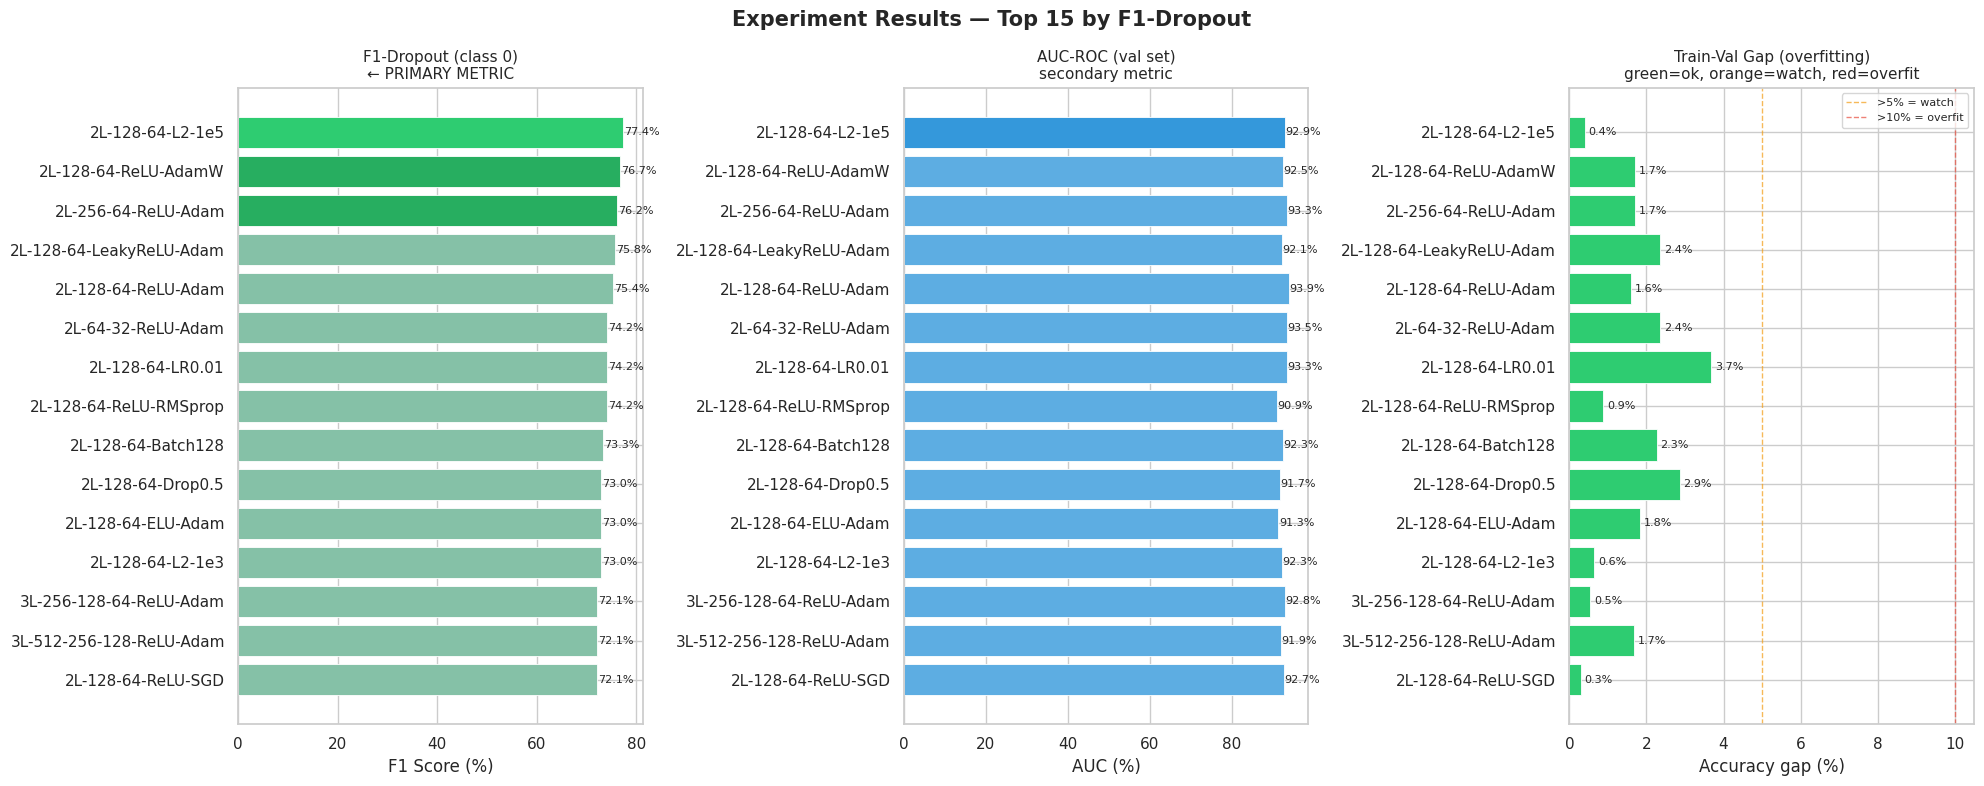

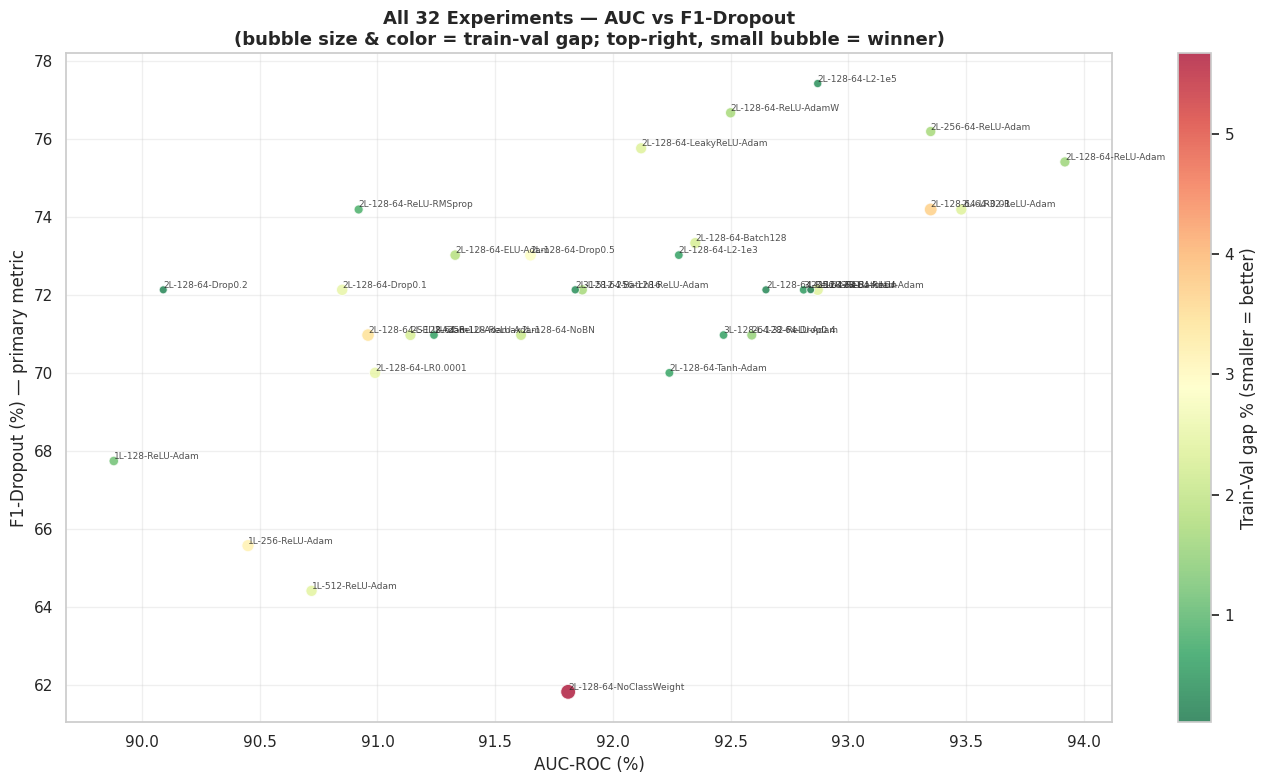

In [67]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 27 — Results Table & Visualisation
# ─────────────────────────────────────────────────────────────────────────────
# Ranked by F1-dropout.
# AUC and gap (overfitting indicator).

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')

ranked = results_df.sort_values('f1_dropout', ascending=False).reset_index(drop=True)
ranked.index += 1

print('=' * 95)
print('  EXPERIMENT RESULTS  (ranked by F1-dropout, val set, threshold=0.50)')
print('=' * 95)
print(f'{"#":>3}  {"Experiment":<38}  {"TrainAcc":>8}  {"ValAcc":>7}  '
      f'{"AUC":>6}  {"F1-drop":>7}  {"F1-per":>6}  {"Gap":>5}  {"Ep":>3}  {"Time":>5}')
print('-' * 95)
for rank, row in ranked.iterrows():
    flag = ' <-- BEST' if rank == 1 else ''
    print(f'{rank:>3}  {row.experiment:<38}  {row.train_acc:>7.2f}%  '
          f'{row.val_acc:>6.2f}%  {row.val_auc:>5.2f}%  '
          f'{row.f1_dropout:>6.2f}%  {row.f1_persist:>5.2f}%  '
          f'{row.gap:>4.2f}%  {row.epochs:>3}  {row.time_s:>4.1f}s{flag}')
print('=' * 95)

top15 = ranked.head(15)

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
fig.suptitle('Experiment Results — Top 15 by F1-Dropout', fontsize=15, fontweight='bold')

colors_f1 = ['#2ECC71' if i == 0 else ('#27AE60' if i < 3 else '#85C1A7')
             for i in range(len(top15))]

bars = axes[0].barh(top15['experiment'][::-1], top15['f1_dropout'][::-1],
                    color=colors_f1[::-1], edgecolor='white', linewidth=0.6)
for bar, val in zip(bars, top15['f1_dropout'][::-1]):
    axes[0].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=8)
axes[0].set_title('F1-Dropout (class 0)\n← PRIMARY METRIC', fontsize=11)
axes[0].set_xlabel('F1 Score (%)')

colors_auc = ['#3498DB' if i == 0 else '#5DADE2'
              for i in range(len(top15))]
bars2 = axes[1].barh(top15['experiment'][::-1], top15['val_auc'][::-1],
                     color=colors_auc[::-1], edgecolor='white', linewidth=0.6)
for bar, val in zip(bars2, top15['val_auc'][::-1]):
    axes[1].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=8)
axes[1].set_title('AUC-ROC (val set)\nsecondary metric', fontsize=11)
axes[1].set_xlabel('AUC (%)')

colors_gap = ['#E74C3C' if g > 10 else ('#F39C12' if g > 5 else '#2ECC71')
              for g in top15['gap'][::-1]]
bars3 = axes[2].barh(top15['experiment'][::-1], top15['gap'][::-1],
                     color=colors_gap, edgecolor='white', linewidth=0.6)
for bar, val in zip(bars3, top15['gap'][::-1]):
    axes[2].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=8)
axes[2].axvline(5,  color='#F39C12', linestyle='--', linewidth=1, alpha=0.7, label='>5% = watch')
axes[2].axvline(10, color='#E74C3C', linestyle='--', linewidth=1, alpha=0.7, label='>10% = overfit')
axes[2].legend(fontsize=8)
axes[2].set_title('Train-Val Gap (overfitting)\ngreen=ok, orange=watch, red=overfit', fontsize=11)
axes[2].set_xlabel('Accuracy gap (%)')

plt.tight_layout()
plt.savefig('experiment_results.png', dpi=150, bbox_inches='tight')
plt.show()

fig2, ax = plt.subplots(figsize=(14, 8))
sc = ax.scatter(
    ranked['val_auc'], ranked['f1_dropout'],
    s=ranked['gap'] * 15 + 30,
    c=ranked['gap'], cmap='RdYlGn_r',
    alpha=0.75, edgecolors='white', linewidth=0.8
)
for _, row in ranked.iterrows():
    ax.annotate(row['experiment'], (row['val_auc'], row['f1_dropout']),
                fontsize=6.5, ha='left', va='bottom', alpha=0.8)
plt.colorbar(sc, ax=ax, label='Train-Val gap % (smaller = better)')
ax.set_xlabel('AUC-ROC (%)')
ax.set_ylabel('F1-Dropout (%) — primary metric')
ax.set_title('All 32 Experiments — AUC vs F1-Dropout\n'
             '(bubble size & color = train-val gap; top-right, small bubble = winner)',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('experiment_bubble.png', dpi=150, bbox_inches='tight')
plt.show()


### CELL 28 — Select Winner & Retrain Best Model

In [68]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 28 — Retrain the Best Configuration
# ─────────────────────────────────────────────────────────────────────────────

best_name = ranked.iloc[0]['experiment']
best_cfg  = next(c for c in EXPERIMENTS if c['name'] == best_name)

print('=' * 60)
print('  WINNER')
print('=' * 60)
print(f'  Config name   : {best_name}')
print(f'  Architecture  : {best_cfg["layers"]}')
print(f'  Activation    : {best_cfg["act"]}')
print(f'  Optimizer     : {best_cfg["opt"]}')
print(f'  Dropout       : {best_cfg["drop"]}')
print(f'  BatchNorm     : {best_cfg["bn"]}')
print(f'  Batch size    : {best_cfg["bs"]}')
print(f'  Learning rate : {best_cfg["lr"]}')
print(f'  F1-dropout (val, 0.50): {ranked.iloc[0]["f1_dropout"]:.2f}%')
print(f'  AUC (val)     : {ranked.iloc[0]["val_auc"]:.2f}%')
print(f'  Train-val gap : {ranked.iloc[0]["gap"]:.2f}%')
print('=' * 60)

# Retrain with full epochs + checkpoint
print('\nRetraining best config with max 200 epochs...')
tf.keras.backend.clear_session()
tf.random.set_seed(42)

model = build_experiment_model(best_cfg, n_features)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=20,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=10, min_lr=1e-6, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath='best_model.keras',
        monitor='val_loss', save_best_only=True, verbose=0
    ),
]

history = model.fit(
    X_train_np, y_train_np,
    validation_data=(X_val_np, y_val_np),
    epochs=200,
    batch_size=best_cfg['bs'],
    class_weight=None if best_cfg.get('no_cw') else class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

best_epoch = np.argmin(history.history['val_loss']) + 1
print(f'\nBest model retrained!')
print(f'  Best epoch    : {best_epoch}')
print(f'  Best val_loss : {min(history.history["val_loss"]):.4f}')
print(f'  Best val_auc  : {history.history["val_auc"][best_epoch-1]:.4f}')
print('\nThis model is now ready for threshold tuning and test evaluation.')


  WINNER
  Config name   : 2L-128-64-L2-1e5
  Architecture  : [128, 64]
  Activation    : relu
  Optimizer     : adam
  Dropout       : 0.3
  BatchNorm     : True
  Batch size    : 32
  Learning rate : 0.001
  F1-dropout (val, 0.50): 77.42%
  AUC (val)     : 92.87%
  Train-val gap : 0.40%

Retraining best config with max 200 epochs...
Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step - accuracy: 0.6657 - auc: 0.7791 - loss: 0.5965 - precision: 0.9115 - recall: 0.6401 - val_accuracy: 0.8264 - val_auc: 0.8459 - val_loss: 0.4888 - val_precision: 0.9238 - val_recall: 0.8509 - learning_rate: 0.0010
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7707 - auc: 0.8613 - loss: 0.4852 - precision: 0.9456 - recall: 0.7538 - val_accuracy: 0.8542 - val_auc: 0.8751 - val_loss: 0.4710 - val_precision: 0.9429 - val_recall: 0.8684 - learning_rate: 0.0010
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8134 - auc: 0.8812 - loss: 0.4418 - precision: 0.9478 - recall: 0.

---
## BRIDGE — Winner model is ready

In [69]:
# ─────────────────────────────────────────────────────────────────────────────
# BRIDGE CELL — Confirm winner model is in memory
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np

print('Winner model summary:')
print(f'  Name          : {model.name}')
print(f'  Config        : {best_name}')
print(f'  Parameters    : {model.count_params():,}')
print(f'  Best val AUC  : {history.history["val_auc"][best_epoch-1]:.4f}')
print(f'  Best val loss : {min(history.history["val_loss"]):.4f}')
print(f'  Best epoch    : {best_epoch}')

# Numpy arrays needed for all subsequent cells
X_train_np = X_train.values.astype(np.float32)
X_val_np   = X_val.values.astype(np.float32)
X_test_np  = X_test.values.astype(np.float32)
y_train_np = y_train.values.astype(np.float32)
y_val_np   = y_val.values.astype(np.float32)
y_test_np  = y_test.values.astype(np.float32)

# Colour palette (needed for charts below)
CLR_PERSIST = '#2ECC71'
CLR_DROPOUT = '#E74C3C'
CLR_NEUTRAL = '#3498DB'

print('\n  Ready!.')


Winner model summary:
  Name          : functional
  Config        : 2L-128-64-L2-1e5
  Parameters    : 11,649
  Best val AUC  : 0.9167
  Best val loss : 0.2989
  Best epoch    : 37

  Ready!.


In [70]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 30 — Compute Class Weights
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes.astype(int), weights))

print('Class weights:')
for cls, w in class_weight_dict.items():
    label = 'Persisted' if cls == 1 else 'Did not persist'
    print(f'  Class {cls} ({label}): weight = {w:.4f}')

ratio = class_weight_dict[0] / class_weight_dict[1]
print(f'\n  Dropout mistakes are penalised {ratio:.1f}x more than persist mistakes.')
print('  This directly compensates for the class imbalance.')


Class weights:
  Class 0 (Did not persist): weight = 2.4040
  Class 1 (Persisted): weight = 0.6313

  Dropout mistakes are penalised 3.8x more than persist mistakes.
  This directly compensates for the class imbalance.


### CELL 31 — Train the Model (Early Stopping + LR Scheduler)

In [71]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 31 — Train the Model
# ─────────────────────────────────────────────────────────────────────────────

X_train_np = X_train.values.astype(np.float32)
X_val_np   = X_val.values.astype(np.float32)
y_train_np = y_train.values.astype(np.float32)
y_val_np   = y_val.values.astype(np.float32)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=20,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=10, min_lr=1e-6, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath='best_model.keras',
        monitor='val_loss', save_best_only=True, verbose=0
    ),
]

print('Training started...\n')
history = model.fit(
    X_train_np, y_train_np,
    validation_data=(X_val_np, y_val_np),
    epochs=200,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

best_epoch = np.argmin(history.history['val_loss']) + 1
print(f'\nTraining complete!')
print(f'  Best epoch        : {best_epoch}')
print(f'  Best val_loss     : {min(history.history["val_loss"]):.4f}')
print(f'  Best val_auc      : {history.history["val_auc"][best_epoch-1]:.4f}')


Training started...

Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8821 - auc: 0.9534 - loss: 0.2670 - precision: 0.9789 - recall: 0.8699 - val_accuracy: 0.8889 - val_auc: 0.9167 - val_loss: 0.2987 - val_precision: 0.9375 - val_recall: 0.9211 - learning_rate: 1.2500e-04
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8756 - auc: 0.9489 - loss: 0.2776 - precision: 0.9749 - recall: 0.8652 - val_accuracy: 0.8819 - val_auc: 0.9165 - val_loss: 0.3007 - val_precision: 0.9369 - val_recall: 0.9123 - learning_rate: 1.2500e-04
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8821 - auc: 0.9565 - loss: 0.2601 - precision: 0.9814 - recall: 0.8675 - val_accuracy: 0.8750 - val_auc: 0.9161 - val_loss: 0.3014 - val_precision: 0.9286 - val_recall: 0.9123 - learning_rate: 1.2500e-04
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8858 - auc: 0.9559 - loss: 0.2571 - precision: 0.9880 - recall: 0.8664 - val_accuracy: 0.8750 - val_auc: 0.

### CELL 32 — Training Curves (Loss, Accuracy, AUC)

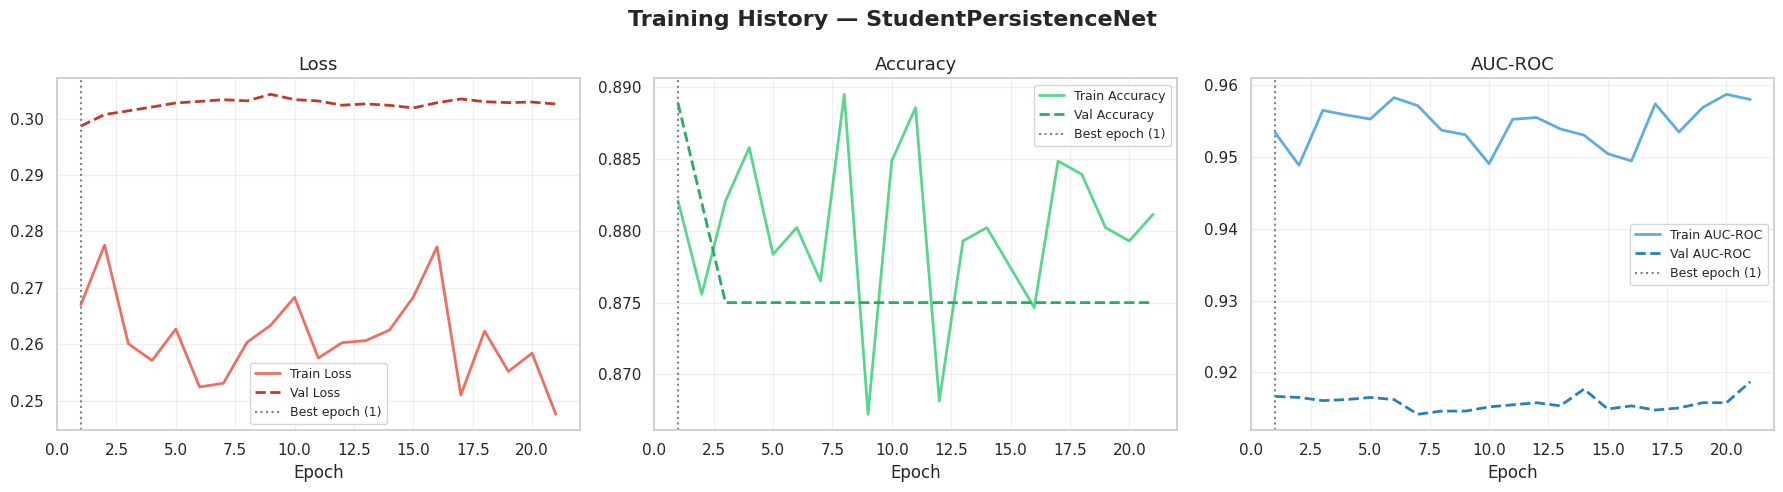

Metrics at best epoch (1):
  Loss      : train=0.2670  val=0.2987  gap=0.0317  [OK]
  Accuracy  : train=0.8821  val=0.8889  gap=0.0068  [OK]
  AUC-ROC   : train=0.9534  val=0.9167  gap=0.0367  [OK]


In [72]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 32 — Training Curves
# ─────────────────────────────────────────────────────────────────────────────

h = history.history
epochs_range = range(1, len(h['loss']) + 1)
best_ep = np.argmin(h['val_loss']) + 1

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training History — StudentPersistenceNet', fontsize=16, fontweight='bold')

metrics = [
    ('loss',     'val_loss',     'Loss',     '#E74C3C', '#C0392B'),
    ('accuracy', 'val_accuracy', 'Accuracy', '#2ECC71', '#27AE60'),
    ('auc',      'val_auc',      'AUC-ROC',  '#3498DB', '#2980B9'),
]

for ax, (train_key, val_key, title, tc, vc) in zip(axes, metrics):
    ax.plot(epochs_range, h[train_key], color=tc, linewidth=2, alpha=0.8, label=f'Train {title}')
    ax.plot(epochs_range, h[val_key],   color=vc, linewidth=2, linestyle='--', label=f'Val {title}')
    ax.axvline(best_ep, color='gray', linestyle=':', linewidth=1.5, label=f'Best epoch ({best_ep})')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Metrics at best epoch ({best_ep}):')
for train_key, val_key, title, _, _ in metrics:
    tv = h[train_key][best_ep-1]
    vv = h[val_key][best_ep-1]
    gap = abs(tv - vv)
    status = 'OK' if gap < 0.05 else 'Watch for overfit'
    print(f'  {title:<10}: train={tv:.4f}  val={vv:.4f}  gap={gap:.4f}  [{status}]')


### CELL 29 — Validation Evaluation (Confusion Matrix, ROC, Report)

> **Confusion Matrix layout:**
> ```
>                  Predicted 0    Predicted 1
>   Actual 0 (drop)    TN              FP   
>   Actual 1 (persist) FN              TP   
> ```

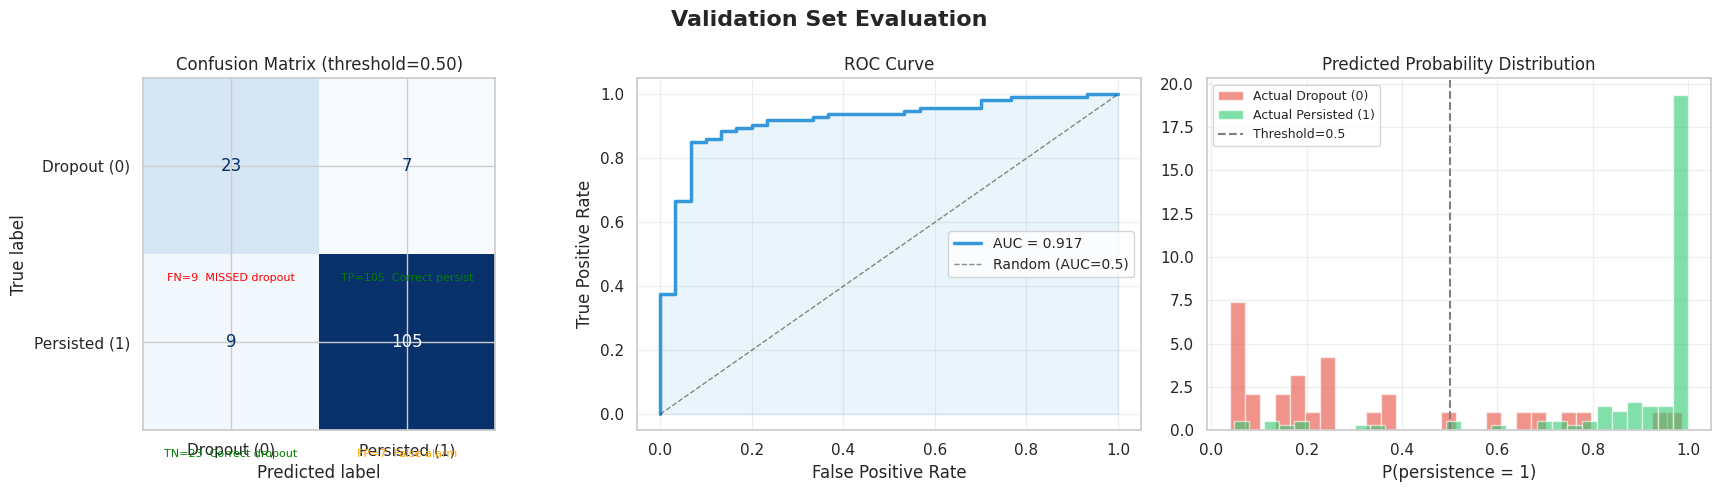

Classification Report - Validation Set:
               precision    recall  f1-score   support

  Dropout (0)       0.72      0.77      0.74        30
Persisted (1)       0.94      0.92      0.93       114

     accuracy                           0.89       144
    macro avg       0.83      0.84      0.84       144
 weighted avg       0.89      0.89      0.89       144



In [73]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 33 — Validation Set Evaluation
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.metrics import (confusion_matrix, classification_report,
                              ConfusionMatrixDisplay, roc_curve, auc)

y_val_prob = model.predict(X_val_np, verbose=0).flatten()
y_val_pred = (y_val_prob >= 0.5).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Validation Set Evaluation', fontsize=16, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_val_np, y_val_pred)
ConfusionMatrixDisplay(cm, display_labels=['Dropout (0)', 'Persisted (1)']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (threshold=0.50)', fontsize=12)
tn, fp, fn, tp = cm.ravel()
axes[0].text(0, 1.65, f'TN={tn}  Correct dropout', ha='center', fontsize=8, color='green')
axes[0].text(1, 1.65, f'FP={fp}  False alarm',     ha='center', fontsize=8, color='orange')
axes[0].text(0, 0.65, f'FN={fn}  MISSED dropout',  ha='center', fontsize=8, color='red')
axes[0].text(1, 0.65, f'TP={tp}  Correct persist', ha='center', fontsize=8, color='green')

# ROC Curve
fpr, tpr, _ = roc_curve(y_val_np, y_val_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#3498DB', linewidth=2.5, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC=0.5)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#3498DB')
axes[1].set_title('ROC Curve', fontsize=12)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Probability distribution
axes[2].hist(y_val_prob[y_val_np==0], bins=30, alpha=0.6, color=CLR_DROPOUT,
             label='Actual Dropout (0)', density=True)
axes[2].hist(y_val_prob[y_val_np==1], bins=30, alpha=0.6, color=CLR_PERSIST,
             label='Actual Persisted (1)', density=True)
axes[2].axvline(0.5, color='gray', linestyle='--', linewidth=1.5, label='Threshold=0.5')
axes[2].set_title('Predicted Probability Distribution', fontsize=12)
axes[2].set_xlabel('P(persistence = 1)')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('validation_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Classification Report - Validation Set:')
print(classification_report(y_val_np, y_val_pred,
      target_names=['Dropout (0)', 'Persisted (1)']))


### CELL 34 — Threshold Tuning

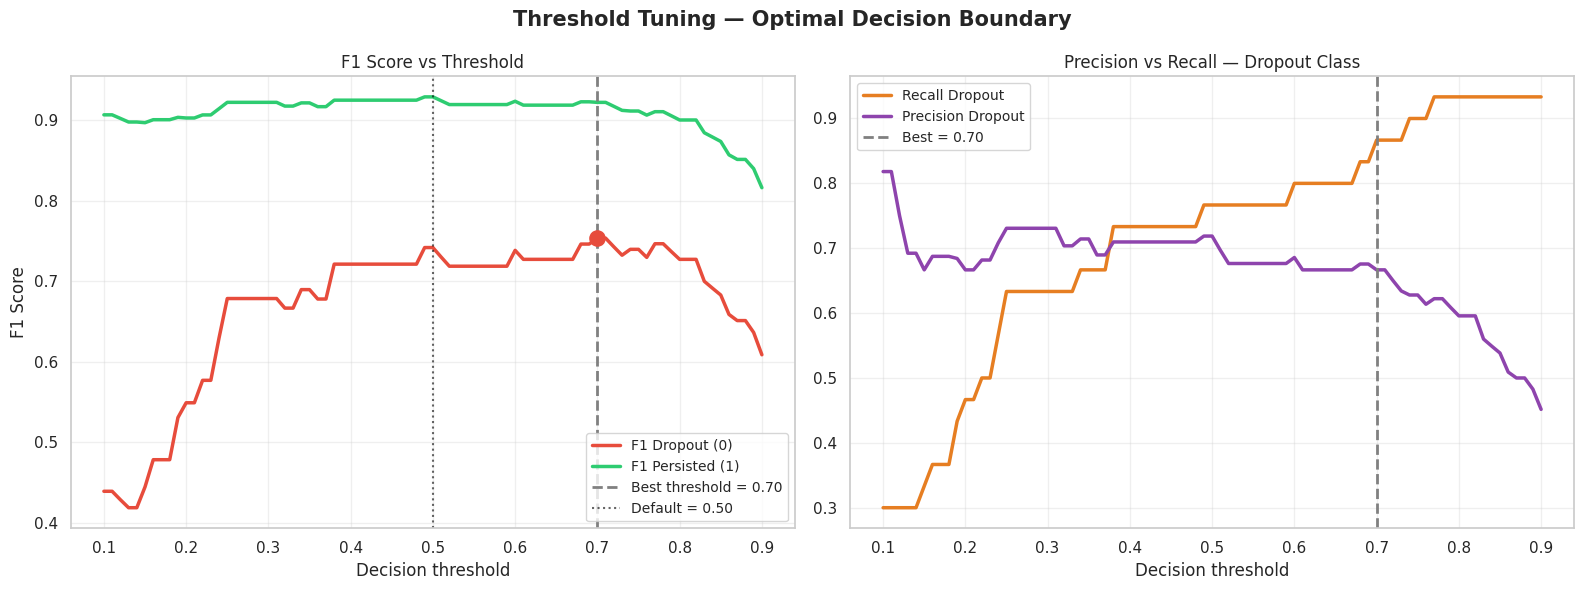

Optimal threshold (max F1 dropout): 0.70
  F1-dropout  : 0.7536
  Recall      : 0.8667
  Precision   : 0.6667
  Compare default 0.50 F1-dropout: 0.7419


In [74]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 34 — Threshold Tuning
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.metrics import f1_score, precision_score, recall_score

thresholds = np.arange(0.10, 0.91, 0.01)
f1_drop, f1_per, rec_drop, prec_drop = [], [], [], []

for t in thresholds:
    y_pred_t = (y_val_prob >= t).astype(int)
    f1_drop.append( f1_score(y_val_np, y_pred_t, pos_label=0, zero_division=0))
    f1_per.append(  f1_score(y_val_np, y_pred_t, pos_label=1, zero_division=0))
    rec_drop.append( recall_score(y_val_np, y_pred_t, pos_label=0, zero_division=0))
    prec_drop.append(precision_score(y_val_np, y_pred_t, pos_label=0, zero_division=0))

best_thresh_idx = np.argmax(f1_drop)
best_thresh     = thresholds[best_thresh_idx]
best_f1_drop    = f1_drop[best_thresh_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Threshold Tuning — Optimal Decision Boundary', fontsize=15, fontweight='bold')

# F1 curves
axes[0].plot(thresholds, f1_drop, color=CLR_DROPOUT, linewidth=2.5, label='F1 Dropout (0)')
axes[0].plot(thresholds, f1_per,  color=CLR_PERSIST, linewidth=2.5, label='F1 Persisted (1)')
axes[0].axvline(best_thresh, color='gray', linestyle='--', linewidth=2,
                label=f'Best threshold = {best_thresh:.2f}')
axes[0].axvline(0.5, color='black', linestyle=':', linewidth=1.5, alpha=0.6, label='Default = 0.50')
axes[0].scatter([best_thresh], [best_f1_drop], color=CLR_DROPOUT, s=120, zorder=5)
axes[0].set_title('F1 Score vs Threshold')
axes[0].set_xlabel('Decision threshold')
axes[0].set_ylabel('F1 Score')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Precision-Recall tradeoff
axes[1].plot(thresholds, rec_drop,  color='#E67E22', linewidth=2.5, label='Recall Dropout')
axes[1].plot(thresholds, prec_drop, color='#8E44AD', linewidth=2.5, label='Precision Dropout')
axes[1].axvline(best_thresh, color='gray', linestyle='--', linewidth=2,
                label=f'Best = {best_thresh:.2f}')
axes[1].set_title('Precision vs Recall — Dropout Class')
axes[1].set_xlabel('Decision threshold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Optimal threshold (max F1 dropout): {best_thresh:.2f}')
print(f'  F1-dropout  : {best_f1_drop:.4f}')
print(f'  Recall      : {rec_drop[best_thresh_idx]:.4f}')
print(f'  Precision   : {prec_drop[best_thresh_idx]:.4f}')
def50 = np.argmin(np.abs(thresholds - 0.50))
print(f'  Compare default 0.50 F1-dropout: {f1_drop[def50]:.4f}')


### CELL 35 — Final Evaluation on TEST Set

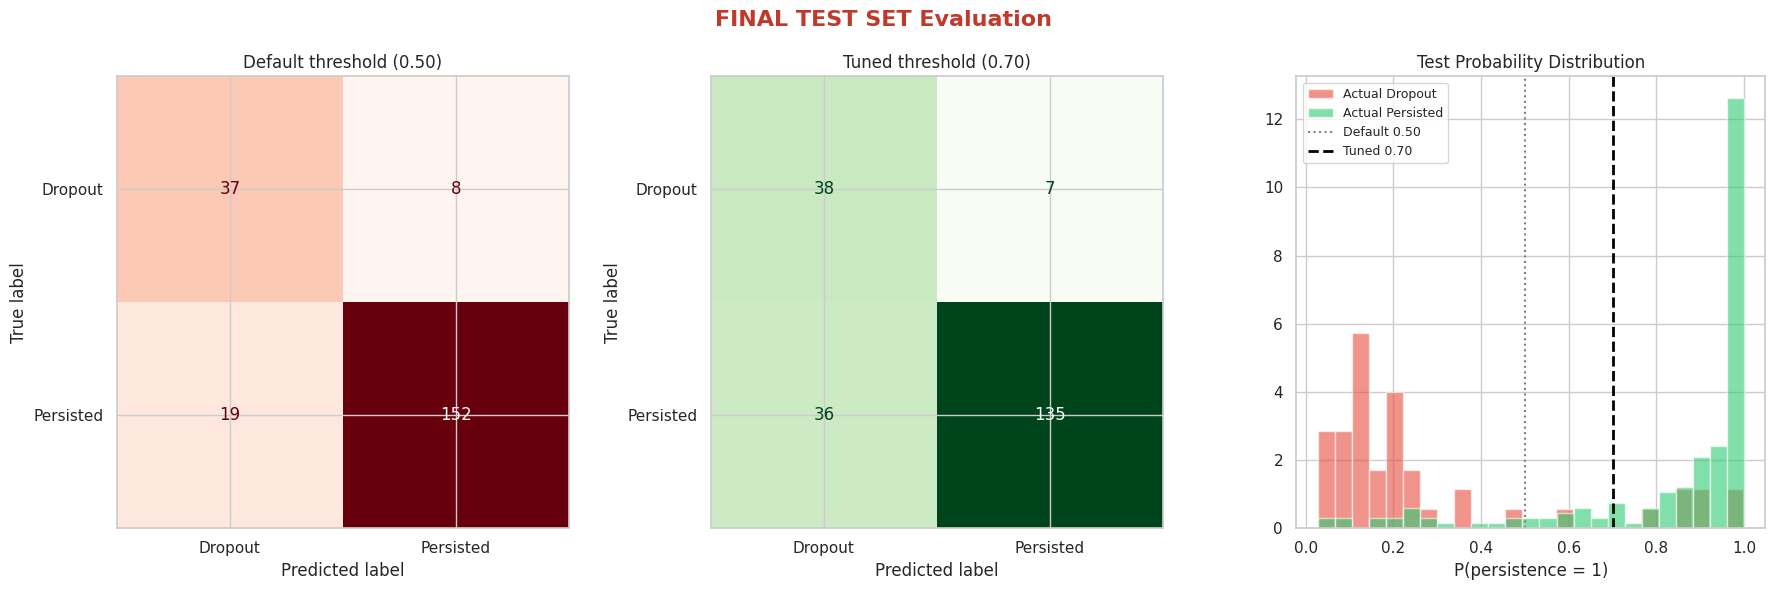

  FINAL TEST — DEFAULT THRESHOLD (0.50)
               precision    recall  f1-score   support

  Dropout (0)       0.66      0.82      0.73        45
Persisted (1)       0.95      0.89      0.92       171

     accuracy                           0.88       216
    macro avg       0.81      0.86      0.83       216
 weighted avg       0.89      0.88      0.88       216

  FINAL TEST — TUNED THRESHOLD (0.70)
               precision    recall  f1-score   support

  Dropout (0)       0.51      0.84      0.64        45
Persisted (1)       0.95      0.79      0.86       171

     accuracy                           0.80       216
    macro avg       0.73      0.82      0.75       216
 weighted avg       0.86      0.80      0.82       216

AUC-ROC on test set: 0.9025


In [75]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 35 — Final Evaluation on TEST Set
# ─────────────────────────────────────────────────────────────────────────────

X_test_np = X_test.values.astype(np.float32)
y_test_np = y_test.values.astype(np.float32)

y_test_prob       = model.predict(X_test_np, verbose=0).flatten()
y_test_pred_def   = (y_test_prob >= 0.50).astype(int)
y_test_pred_tuned = (y_test_prob >= best_thresh).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('FINAL TEST SET Evaluation', fontsize=16, fontweight='bold', color='#C0392B')

# Default threshold CM
cm_d = confusion_matrix(y_test_np, y_test_pred_def)
ConfusionMatrixDisplay(cm_d, display_labels=['Dropout','Persisted']).plot(
    ax=axes[0], colorbar=False, cmap='Reds')
axes[0].set_title('Default threshold (0.50)', fontsize=12)

# Tuned threshold CM
cm_t = confusion_matrix(y_test_np, y_test_pred_tuned)
ConfusionMatrixDisplay(cm_t, display_labels=['Dropout','Persisted']).plot(
    ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title(f'Tuned threshold ({best_thresh:.2f})', fontsize=12)

# Probability distribution
axes[2].hist(y_test_prob[y_test_np==0], bins=25, alpha=0.6,
             color=CLR_DROPOUT, label='Actual Dropout', density=True)
axes[2].hist(y_test_prob[y_test_np==1], bins=25, alpha=0.6,
             color=CLR_PERSIST, label='Actual Persisted', density=True)
axes[2].axvline(0.5,        color='gray',  linestyle=':',  linewidth=1.5, label='Default 0.50')
axes[2].axvline(best_thresh, color='black', linestyle='--', linewidth=2,
                label=f'Tuned {best_thresh:.2f}')
axes[2].set_title('Test Probability Distribution', fontsize=12)
axes[2].set_xlabel('P(persistence = 1)')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('test_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

from sklearn.metrics import roc_auc_score
print('=' * 55)
print('  FINAL TEST — DEFAULT THRESHOLD (0.50)')
print('=' * 55)
print(classification_report(y_test_np, y_test_pred_def,
      target_names=['Dropout (0)', 'Persisted (1)']))

print('=' * 55)
print(f'  FINAL TEST — TUNED THRESHOLD ({best_thresh:.2f})')
print('=' * 55)
print(classification_report(y_test_np, y_test_pred_tuned,
      target_names=['Dropout (0)', 'Persisted (1)']))

print(f'AUC-ROC on test set: {roc_auc_score(y_test_np, y_test_prob):.4f}')


### CELL 32 — Save Everything for the Backend

In [76]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 36 — Save All Artefacts
# ─────────────────────────────────────────────────────────────────────────────
# Artefacts:
#   best_model.keras      -> trained neural network weights
#   scaler.pkl            -> StandardScaler (fit on train)
#   ohe_funding.pkl       -> OneHotEncoder for funding column
#   knn_imputer.pkl       -> KNN imputer (fit on train)
#   group_medians.pkl     -> group-wise medians for GPA/math
#   train_modes.pkl       -> modes for categorical imputation
#   pipeline_config.json  -> feature names, thresholds, column order

import joblib, json, os

model.save('best_model.keras')
print('  best_model.keras saved')

for obj, fname in [
    (scaler,      'scaler.pkl'),
    (ohe,         'ohe_funding.pkl'),
    (knn_imputer, 'knn_imputer.pkl'),
    (gw_medians,  'group_medians.pkl'),
    (train_modes, 'train_modes.pkl'),
]:
    joblib.dump(obj, fname)
    print(f'  {fname} saved')

pipeline_config = {
    'model_name'        : 'StudentPersistenceNet',
    'version'           : '1.0.0',
    'n_features'        : int(n_features),
    'feature_names'     : X_train.columns.tolist(),
    'binary_recode_cols': ['first_language','fast_track','coop',
                           'residency','gender','prev_education'],
    'scale_cols'        : ['first_term_gpa','second_term_gpa','age_group',
                           'hs_avg','math_score','english_grade'],
    'mode_impute_cols'  : ['gender','prev_education','age_group','english_grade'],
    'ohe_col'           : 'funding',
    'knn_neighbors'     : N_NEIGHBORS,
    'default_threshold' : 0.50,
    'tuned_threshold'   : float(round(best_thresh, 2)),
    'target_col'        : 'persistence',
    'class_labels'      : {'0': 'Did not persist', '1': 'Persisted'},
    'valid_ranges'      : {k: list(v) for k, v in VALID_RANGES.items()},
}

with open('pipeline_config.json', 'w') as f:
    json.dump(pipeline_config, f, indent=2)
print('  pipeline_config.json saved')

print('\n' + '=' * 55)
print('  ALL ARTEFACTS SAVED!')
print('  Files to download from Colab:')
for fname in ['best_model.keras','scaler.pkl','ohe_funding.pkl',
              'knn_imputer.pkl','group_medians.pkl','train_modes.pkl',
              'pipeline_config.json']:
    size = os.path.getsize(fname) if os.path.exists(fname) else 0
    print(f'    {fname:<32} {size/1024:.1f} KB')
print('=' * 55)



  best_model.keras saved
  scaler.pkl saved
  ohe_funding.pkl saved
  knn_imputer.pkl saved
  group_medians.pkl saved
  train_modes.pkl saved
  pipeline_config.json saved

  ALL ARTEFACTS SAVED!
  Files to download from Colab:
    best_model.keras                 183.1 KB
    scaler.pkl                       1.1 KB
    ohe_funding.pkl                  0.9 KB
    knn_imputer.pkl                  171.5 KB
    group_medians.pkl                0.1 KB
    train_modes.pkl                  0.2 KB
    pipeline_config.json             1.6 KB
